In [46]:
import os
import sys
sys.path.append(os.path.abspath("../src"))
from optimization_logic import *

In [47]:
import pandas as pd
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
import os

import warnings
warnings.filterwarnings("ignore")

#Plotting styles
# plt.style.use('ggplot')
plt.rcParams.update(
{"figure.figsize": (12, 5),
#  'font.family': 'serif',
"text.usetex": False,
"axes.titlesize" : 12,
"axes.labelsize" : 10,
# "axes.labelweight" : "bold",
"lines.linewidth": 1,
"lines.markersize" : 5,
"legend.fontsize": 8,
"legend.title_fontsize" : 9,
"xtick.labelsize" : 8,
"ytick.labelsize" : 8})

metrics = ['euclidean','cosine', 'correlation']

def create_monthly_tables():
    for metric in metrics:
        df = pd.read_csv(f'../src/data/processed/reference_days_{metric}_table.csv')
        df['date'] = pd.to_datetime(df['date'])
        
        mask = (df['date'].dt.year == 2024) & (df['date'].dt.month.isin([8, 9, 10]))
        filtered_df = df[mask].copy()
        
        filtered_df['date'] = filtered_df['date'].dt.strftime('%Y-%m-%d')
        
        output_path = f'../src/data/processed/reference_days_{metric}_table.csv'
        filtered_df.to_csv(output_path, index=False)
        print(f"Saved {metric} reference days to: {output_path}")

create_monthly_tables()


Saved euclidean reference days to: ../src/data/processed/reference_days_euclidean_table.csv
Saved cosine reference days to: ../src/data/processed/reference_days_cosine_table.csv
Saved correlation reference days to: ../src/data/processed/reference_days_correlation_table.csv


In [34]:
df_euclidean = pd.read_csv('../src/data/processed/reference_days_euclidean_table.csv')
print("\nSample of Euclidean distance reference days:")
df_euclidean.head()



Sample of Euclidean distance reference days:


,date,closest_reference_days,distance
0,2024-07-30,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",1897.129645
1,2024-07-31,"[Timestamp('2024-06-24 00:00:00'), Timestamp('...",1576.997400
2,2024-08-01,"[Timestamp('2024-06-25 00:00:00'), Timestamp('...",1284.936346
3,2024-08-02,"[Timestamp('2024-07-19 00:00:00'), Timestamp('...",3731.901179
4,2024-08-03,"[Timestamp('2024-06-22 00:00:00'), Timestamp('...",2507.087166


In [23]:
# df_weighted_euclidean = pd.read_csv('../src/data/processed/reference_days_weighted_euclidean_table.csv')
# print("\nSample of Weighted Euclidean distance reference days:")
# df_weighted_euclidean.head()


In [35]:
df_cosine = pd.read_csv('../src/data/processed/reference_days_cosine_table.csv')
print("\nSample of Weighted Cosine distance reference days:")
df_cosine.head()


Sample of Weighted Cosine distance reference days:


,date,closest_reference_days,distance
0,2024-07-30,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.000745
1,2024-07-31,"[Timestamp('2024-06-19 00:00:00'), Timestamp('...",0.000575
2,2024-08-01,"[Timestamp('2024-06-25 00:00:00'), Timestamp('...",0.000318
3,2024-08-02,"[Timestamp('2024-06-21 00:00:00'), Timestamp('...",0.002781
4,2024-08-03,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.001405


In [36]:
df_corr = pd.read_csv('../src/data/processed/reference_days_correlation_table.csv')
print("\nSample of Correlation distance reference days:")
df_corr.head()


Sample of Correlation distance reference days:


,date,closest_reference_days,distance
0,2024-07-30,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.001000
1,2024-07-31,"[Timestamp('2024-06-19 00:00:00'), Timestamp('...",0.000673
2,2024-08-01,"[Timestamp('2024-06-25 00:00:00'), Timestamp('...",0.000412
3,2024-08-02,"[Timestamp('2024-06-21 00:00:00'), Timestamp('...",0.003852
4,2024-08-03,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.001891


In [30]:
import pandas as pd

df_euclidean = pd.read_csv('../src/data/processed/reference_days_euclidean_table.csv')
df_cosine = pd.read_csv('../src/data/processed/reference_days_cosine_table.csv')
df_correlation = pd.read_csv('../src/data/processed/reference_days_correlation_table.csv')

print("Euclidean Distance Reference Days:")
df_euclidean.head()



Euclidean Distance Reference Days:


,date,closest_reference_days,distance
0,2024-07-30,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",1897.129645
1,2024-07-31,"[Timestamp('2024-06-24 00:00:00'), Timestamp('...",1576.997400
2,2024-08-01,"[Timestamp('2024-06-25 00:00:00'), Timestamp('...",1284.936346
3,2024-08-02,"[Timestamp('2024-07-19 00:00:00'), Timestamp('...",3731.901179
4,2024-08-03,"[Timestamp('2024-06-22 00:00:00'), Timestamp('...",2507.087166


In [37]:
df_cosine.head()

,date,closest_reference_days,distance
0,2024-07-30,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.000745
1,2024-07-31,"[Timestamp('2024-06-19 00:00:00'), Timestamp('...",0.000575
2,2024-08-01,"[Timestamp('2024-06-25 00:00:00'), Timestamp('...",0.000318
3,2024-08-02,"[Timestamp('2024-06-21 00:00:00'), Timestamp('...",0.002781
4,2024-08-03,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.001405


In [38]:
df_correlation.head()


,date,closest_reference_days,distance
0,2024-07-30,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.001000
1,2024-07-31,"[Timestamp('2024-06-19 00:00:00'), Timestamp('...",0.000673
2,2024-08-01,"[Timestamp('2024-06-25 00:00:00'), Timestamp('...",0.000412
3,2024-08-02,"[Timestamp('2024-06-21 00:00:00'), Timestamp('...",0.003852
4,2024-08-03,"[Timestamp('2024-07-18 00:00:00'), Timestamp('...",0.001891


In [50]:
SIZE = 100               # MWh - default 56.4
POWER_UP = 50            # MW - default 49, 
POWER_DOWN  = 50         # MW - default 49

RTE = 0.88                                # round trip efficiency
CHARGE_EFFICIENCY = np.sqrt(RTE)          #default = sqrt(RTE)
DISCHARGE_EFFICIENCY = np.sqrt(RTE)       #default = sqrt(RTE)

MAX_THROUGHPUT_CYCLES = 2                 # count - default 2.3
THROUGHPUT_SIZE = SIZE                    # MWh
TSTEP = 1                                 # default = 1 for hourly DA market

###############################
#      script technicals      #
###############################

SOLUTION_TIME_LIMIT_SEC = 30  # default 30
INTEGER_PN = False            # default True

###############################
#      DA scpecifics          #
###############################

MANUAL_SOC_MIN = 0           # MWh 
MANUAL_SOC_MAX = SIZE         # MWh

INIT_SOC = 0        # MWh, default = size/2 
END_SOC = 0         # MWh, default = None
end_soc_limit_type = 'equal_to'

###############################
#    Simulation specifics     #
###############################

assume_perfect_foresight = True

###############################
#           Plotting          #
###############################

show_daily_plots = True

###############################
#           Logging           #
###############################

save_setpoint_log = False
save_daily_log = False
save_path = '/simulation_logs/'
save_name_prefix = f'martina_{SIZE}mwh_{POWER_DOWN}mw'


settlement_freq = {0.25: "15min", 0.5: "30min", 1: "H"}


In [49]:
data_files_path = os.getcwd()+'/'
file_name = '../src/data/processed/gb_epex_da_actuals.csv'
main_data = pd.read_csv(data_files_path+'/'+file_name)

In [51]:
main_data.head()

,dtutc,da_price,dtcet,date
0,2023-12-31 23:00:00+00:00,53.2,2024-01-01 00:00:00+01:00,2024-01-01
1,2024-01-01 00:00:00+00:00,50.0,2024-01-01 01:00:00+01:00,2024-01-01
2,2024-01-01 01:00:00+00:00,47.0,2024-01-01 02:00:00+01:00,2024-01-01
3,2024-01-01 02:00:00+00:00,33.0,2024-01-01 03:00:00+01:00,2024-01-01
4,2024-01-01 03:00:00+00:00,25.8,2024-01-01 04:00:00+01:00,2024-01-01


In [52]:
da_data = main_data[["dtutc", "da_price"]].copy()
da_data["dtutc"] = pd.to_datetime(da_data.dtutc, utc=True)

In [53]:
da_data = da_data.resample(settlement_freq[TSTEP], on = "dtutc", origin="start").mean()
da_data

,da_price
dtutc,
2023-12-31 23:00:00+00:00,53.20
2024-01-01 00:00:00+00:00,50.00
2024-01-01 01:00:00+00:00,47.00
2024-01-01 02:00:00+00:00,33.00
2024-01-01 03:00:00+00:00,25.80
...,...
2024-12-31 18:00:00+00:00,86.00
2024-12-31 19:00:00+00:00,52.05
2024-12-31 20:00:00+00:00,36.00


In [54]:
da_data.reset_index(inplace=True)
da_data["dtcet"] = da_data.dtutc.dt.tz_convert("Europe/Brussels")
da_data["date"] = da_data.dtcet.dt.date

In [55]:
da_data[da_data.da_price.isna()]


,dtutc,da_price,dtcet,date


In [56]:
da_data.head()


,dtutc,da_price,dtcet,date
0,2023-12-31 23:00:00+00:00,53.2,2024-01-01 00:00:00+01:00,2024-01-01
1,2024-01-01 00:00:00+00:00,50.0,2024-01-01 01:00:00+01:00,2024-01-01
2,2024-01-01 01:00:00+00:00,47.0,2024-01-01 02:00:00+01:00,2024-01-01
3,2024-01-01 02:00:00+00:00,33.0,2024-01-01 03:00:00+01:00,2024-01-01
4,2024-01-01 03:00:00+00:00,25.8,2024-01-01 04:00:00+01:00,2024-01-01


In [57]:
da_data.tail()

,dtutc,da_price,dtcet,date
8779,2024-12-31 18:00:00+00:00,86.00,2024-12-31 19:00:00+01:00,2024-12-31
8780,2024-12-31 19:00:00+00:00,52.05,2024-12-31 20:00:00+01:00,2024-12-31
8781,2024-12-31 20:00:00+00:00,36.00,2024-12-31 21:00:00+01:00,2024-12-31
8782,2024-12-31 21:00:00+00:00,19.90,2024-12-31 22:00:00+01:00,2024-12-31
8783,2024-12-31 22:00:00+00:00,7.00,2024-12-31 23:00:00+01:00,2024-12-31


In [59]:
dates = df_euclidean.date.unique()
dates

array(['2024-07-30', '2024-07-31', '2024-08-01', '2024-08-02',
       '2024-08-03', '2024-08-04', '2024-08-05', '2024-08-06',
       '2024-08-07', '2024-08-08', '2024-08-09', '2024-08-10',
       '2024-08-11', '2024-08-12', '2024-08-13', '2024-08-14',
       '2024-08-15', '2024-08-16', '2024-08-17', '2024-08-18',
       '2024-08-19', '2024-08-20', '2024-08-21', '2024-08-22',
       '2024-08-23', '2024-08-24', '2024-08-25', '2024-08-26',
       '2024-08-27', '2024-08-28', '2024-08-29', '2024-08-30',
       '2024-08-31', '2024-09-01', '2024-09-02', '2024-09-03',
       '2024-09-04', '2024-09-05', '2024-09-06', '2024-09-07',
       '2024-09-08', '2024-09-09', '2024-09-10', '2024-09-11',
       '2024-09-12', '2024-09-13', '2024-09-14', '2024-09-15',
       '2024-09-16', '2024-09-17', '2024-09-18', '2024-09-19',
       '2024-09-20', '2024-09-21', '2024-09-22', '2024-09-23',
       '2024-09-24', '2024-09-25', '2024-09-26', '2024-09-27',
       '2024-09-28', '2024-09-29', '2024-09-30', '2024-

In [60]:
bess_object_dam = day_ahead(
    size=SIZE,
    power_up=POWER_UP,
    power_down=POWER_DOWN,
    timestep=1,
    charge_eff=CHARGE_EFFICIENCY,
    discharge_eff=DISCHARGE_EFFICIENCY,
    manual_soc_max=MANUAL_SOC_MAX,
    manual_soc_min=MANUAL_SOC_MIN,
    init_soc=INIT_SOC,
    end_soc=END_SOC,
    end_soc_limit_type=end_soc_limit_type,
    daily_cycle_max=MAX_THROUGHPUT_CYCLES,
    throughput_size=THROUGHPUT_SIZE,
    solution_time_limit=SOLUTION_TIME_LIMIT_SEC,
    integer_solution=INTEGER_PN,
)

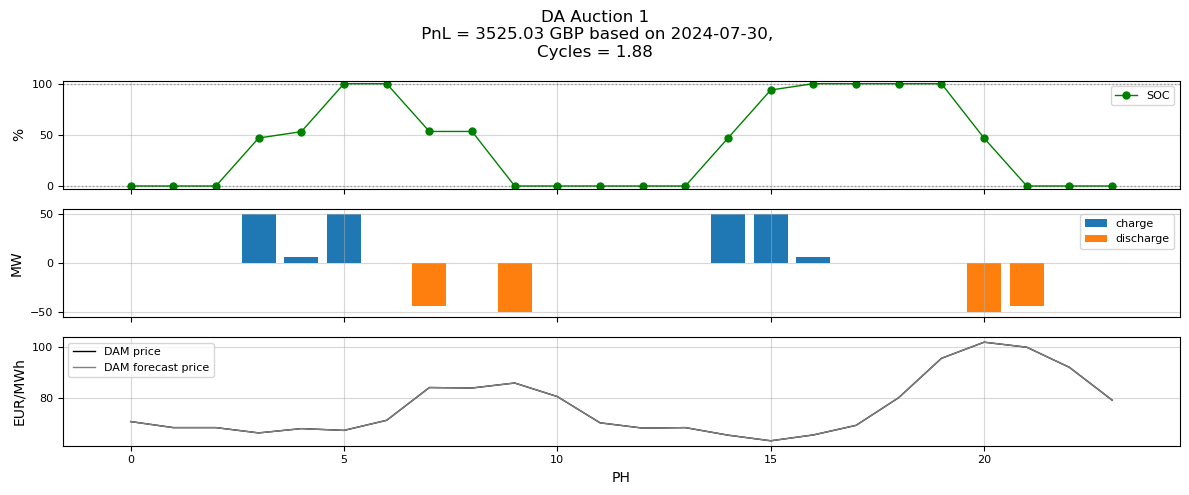

     del_date ref_date   pnl_da
0  2024-07-30     None  3525.03


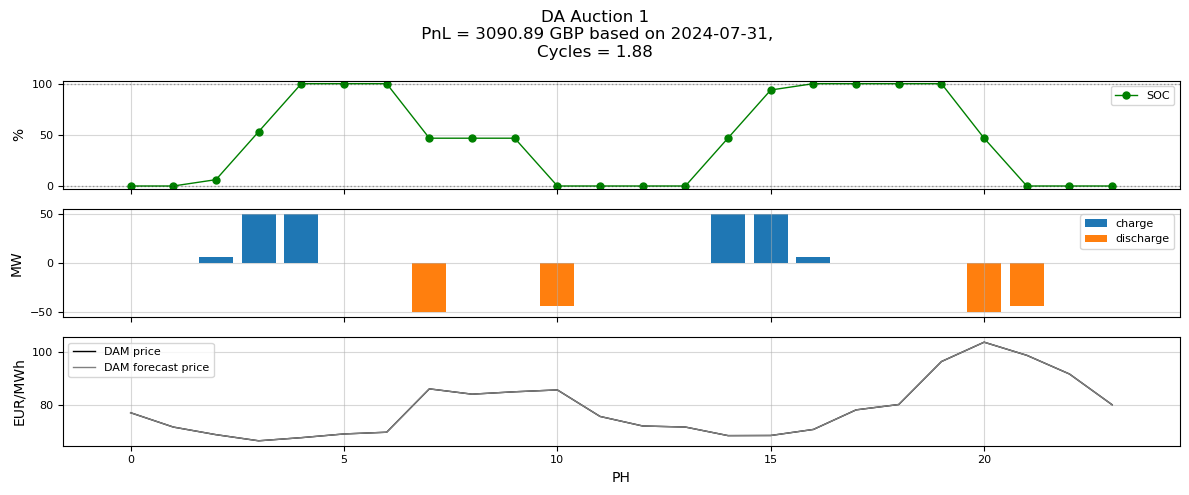

     del_date ref_date   pnl_da
1  2024-07-31     None  3090.89


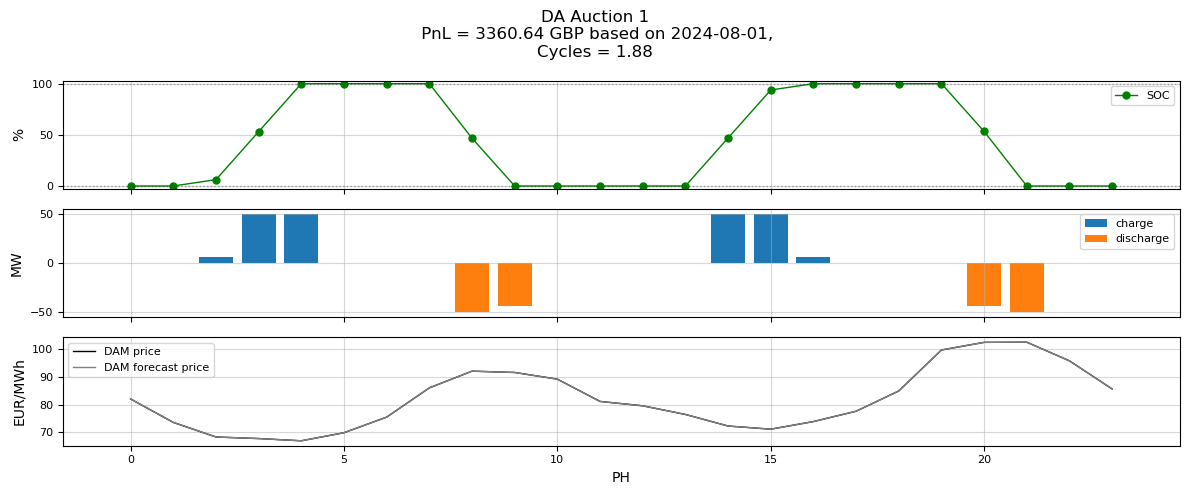

     del_date ref_date   pnl_da
2  2024-08-01     None  3360.64


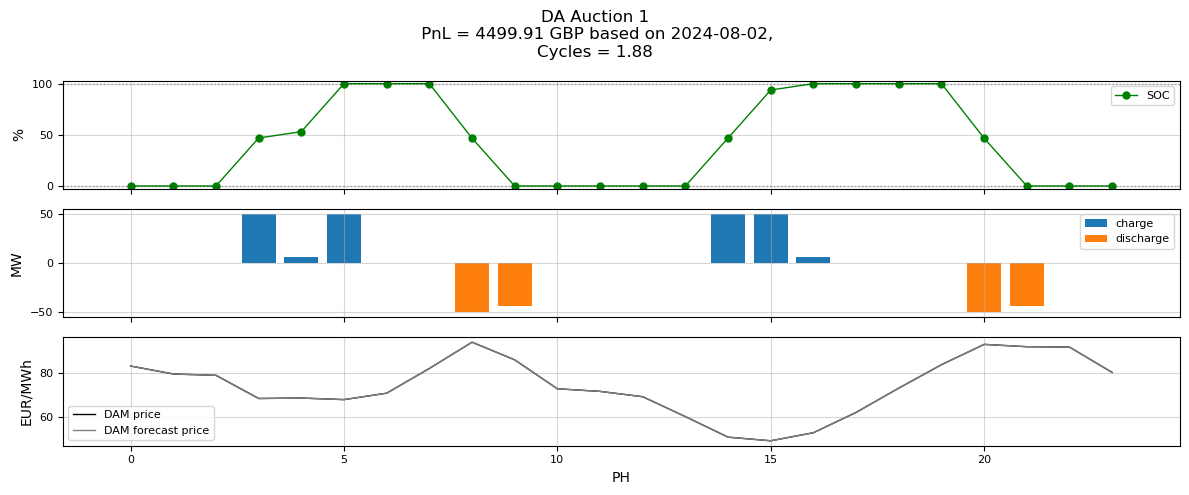

     del_date ref_date   pnl_da
3  2024-08-02     None  4499.91


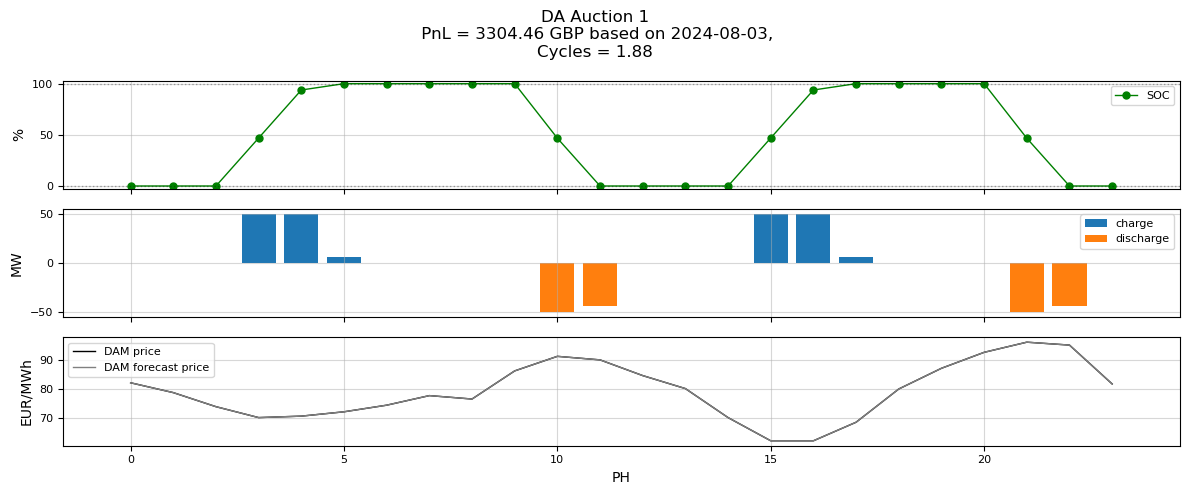

     del_date ref_date   pnl_da
4  2024-08-03     None  3304.46


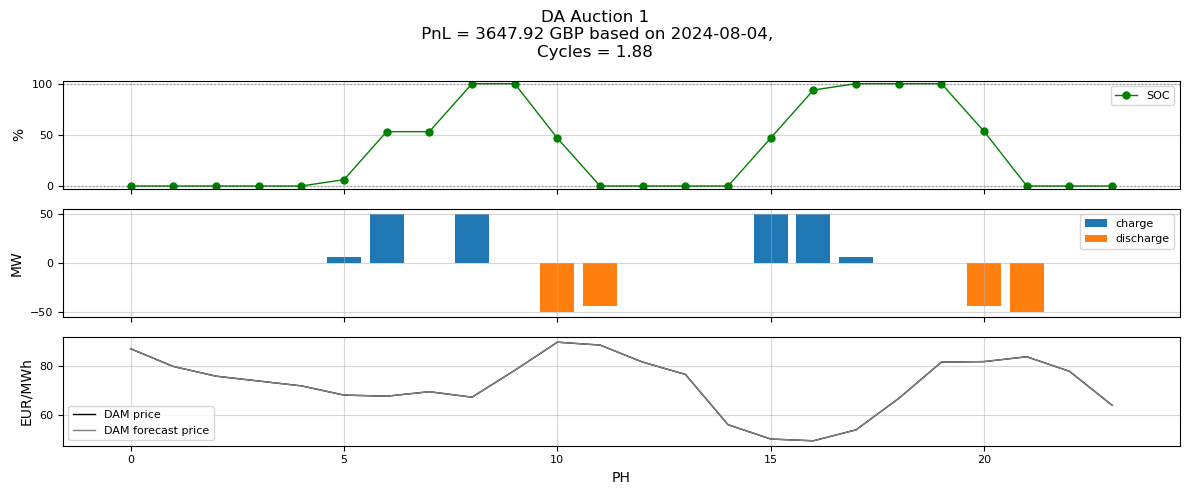

     del_date ref_date   pnl_da
5  2024-08-04     None  3647.92


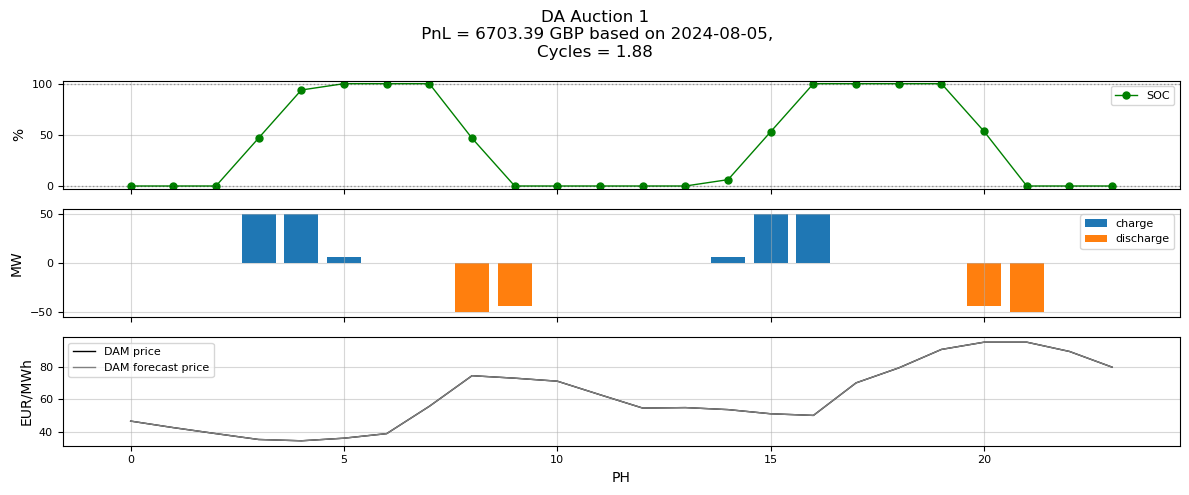

     del_date ref_date   pnl_da
6  2024-08-05     None  6703.39


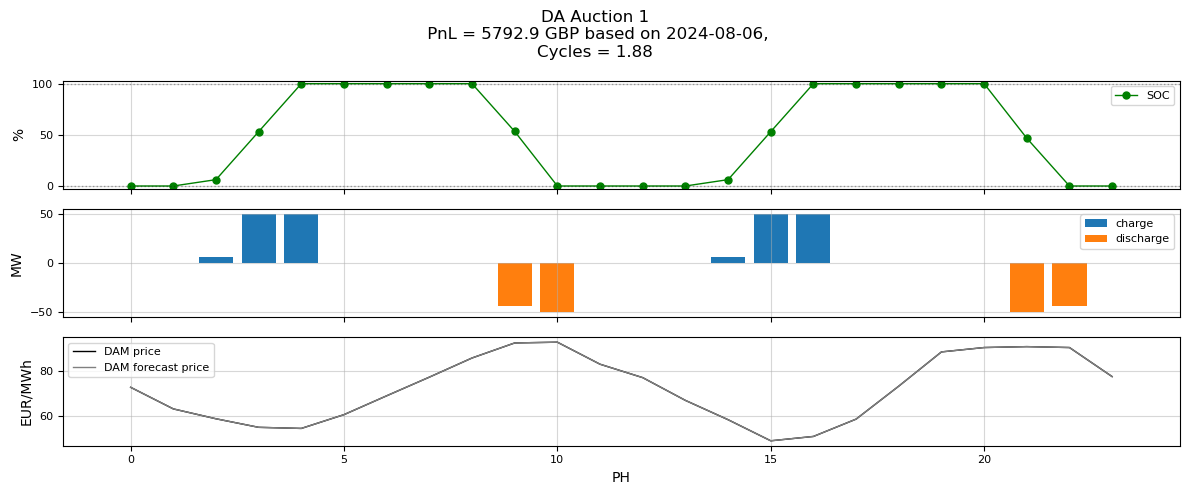

     del_date ref_date  pnl_da
7  2024-08-06     None  5792.9


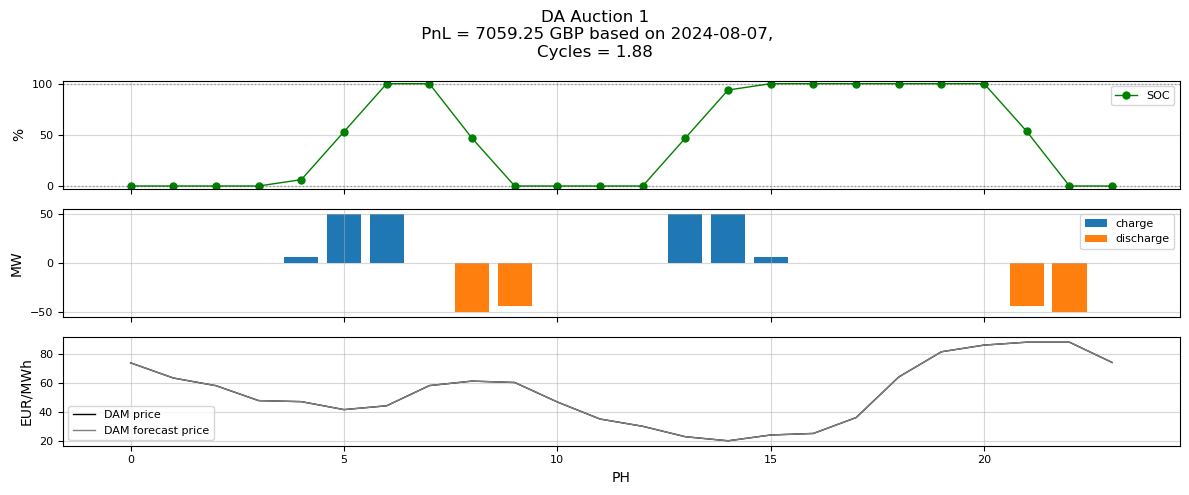

     del_date ref_date   pnl_da
8  2024-08-07     None  7059.25


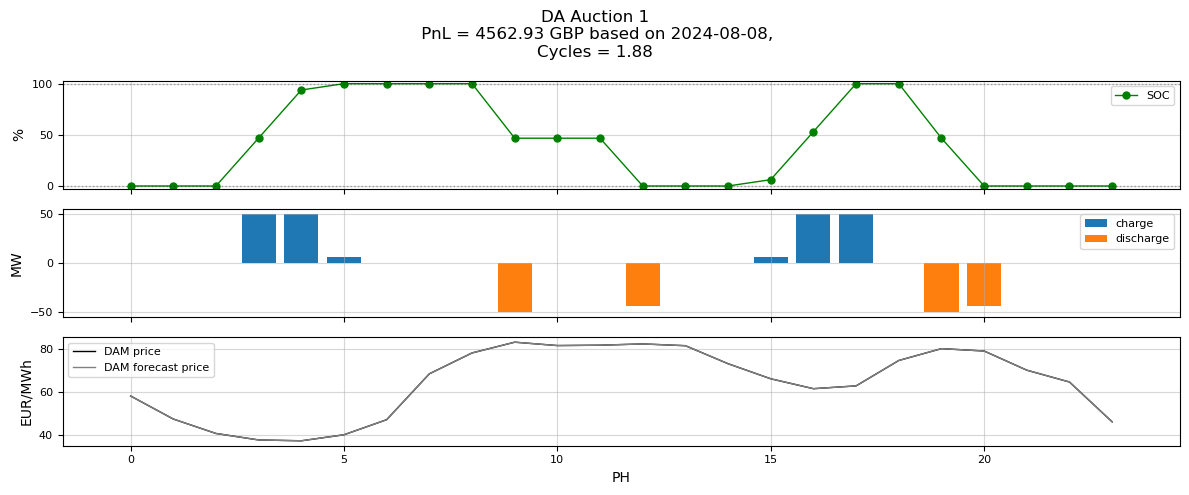

     del_date ref_date   pnl_da
9  2024-08-08     None  4562.93


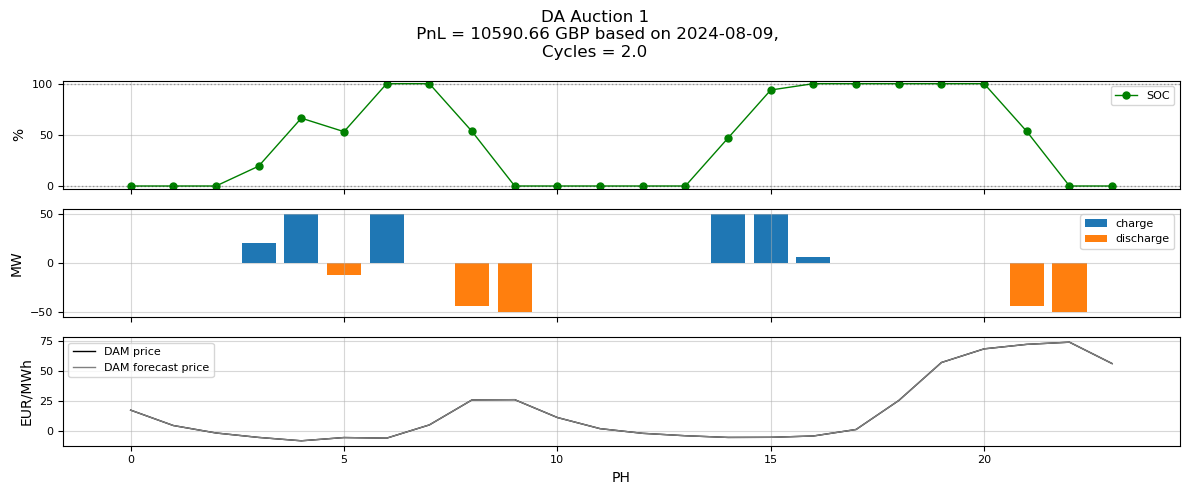

      del_date ref_date    pnl_da
10  2024-08-09     None  10590.66


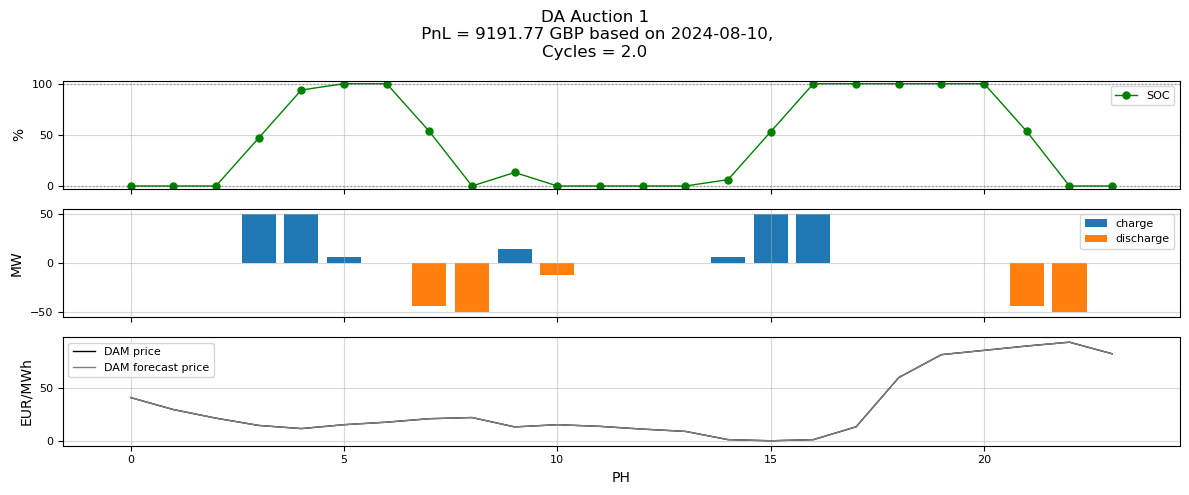

      del_date ref_date   pnl_da
11  2024-08-10     None  9191.77


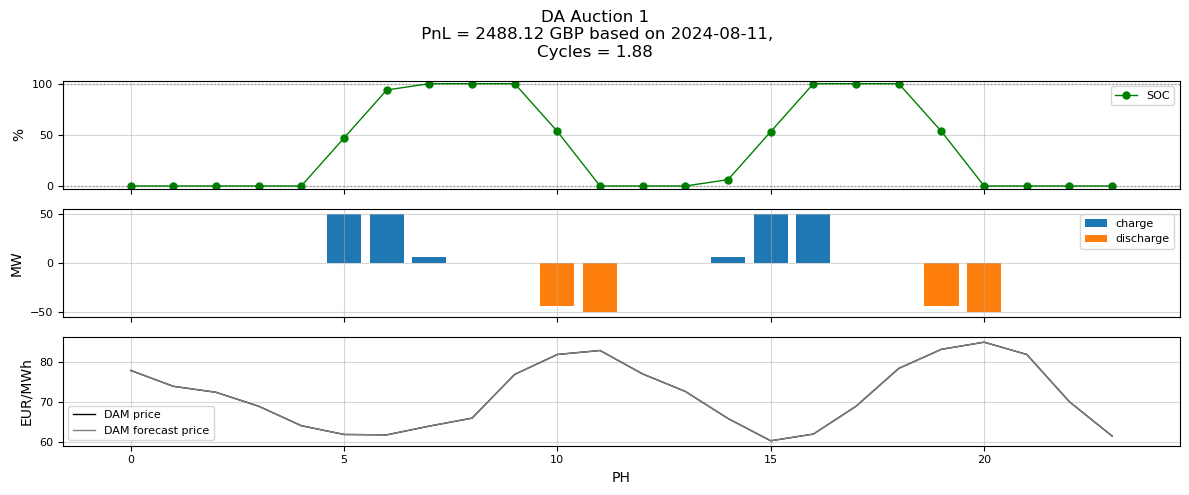

      del_date ref_date   pnl_da
12  2024-08-11     None  2488.12


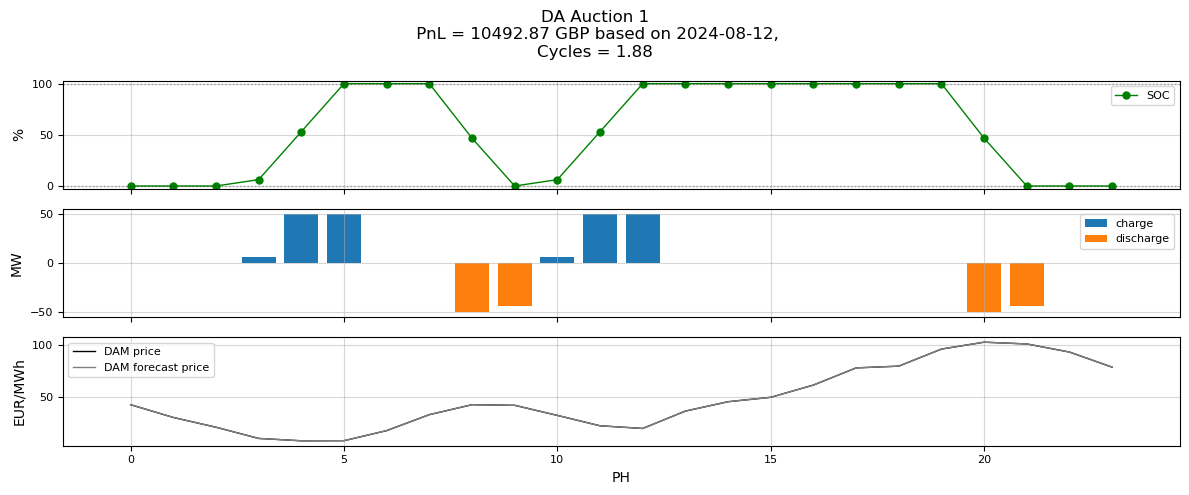

      del_date ref_date    pnl_da
13  2024-08-12     None  10492.87


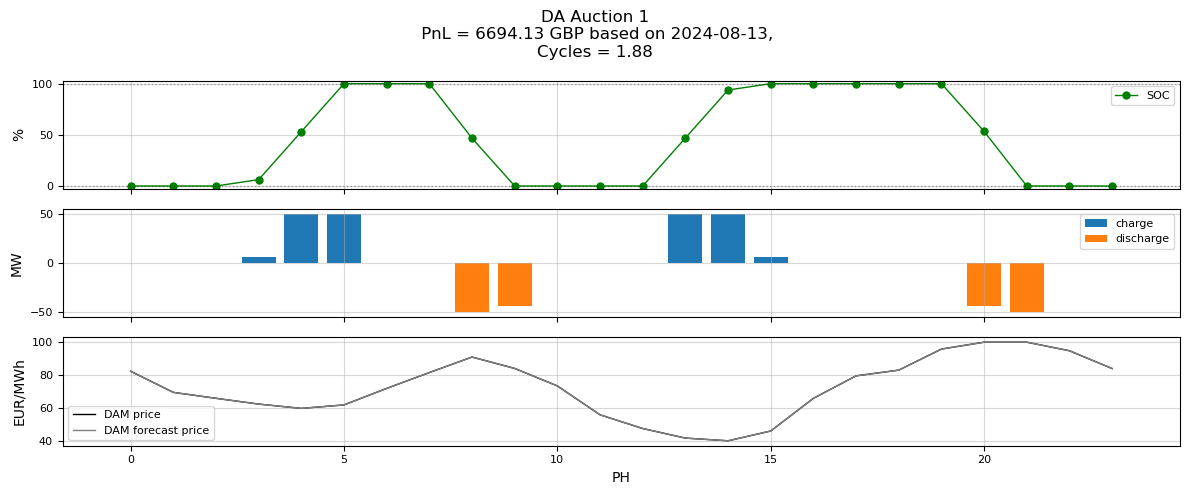

      del_date ref_date   pnl_da
14  2024-08-13     None  6694.13


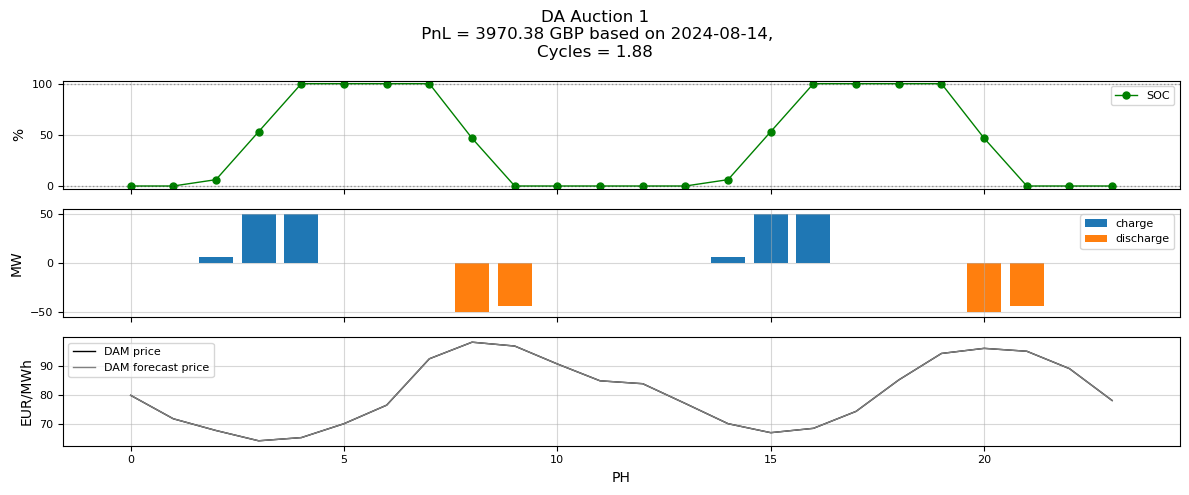

      del_date ref_date   pnl_da
15  2024-08-14     None  3970.38


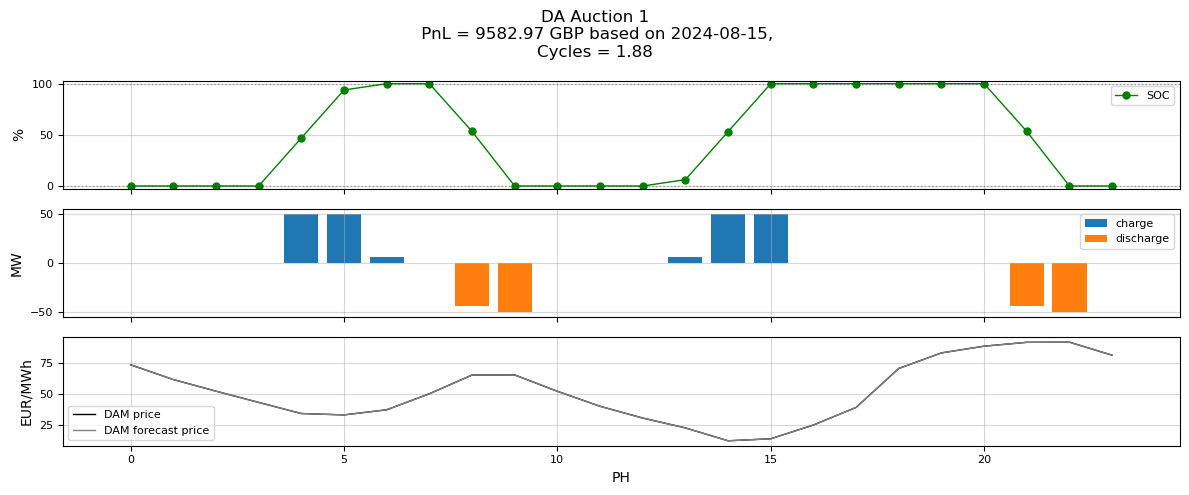

      del_date ref_date   pnl_da
16  2024-08-15     None  9582.97


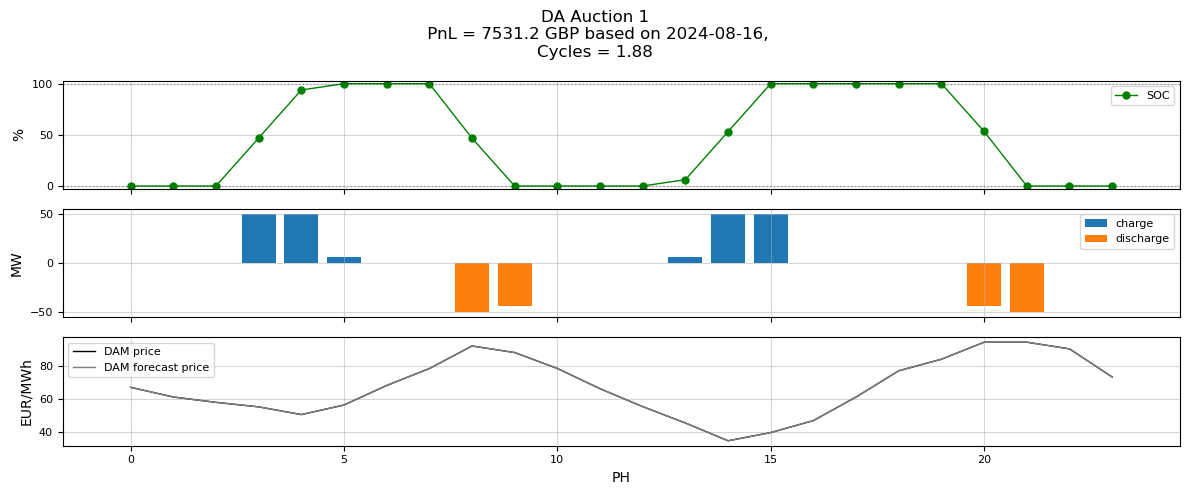

      del_date ref_date  pnl_da
17  2024-08-16     None  7531.2


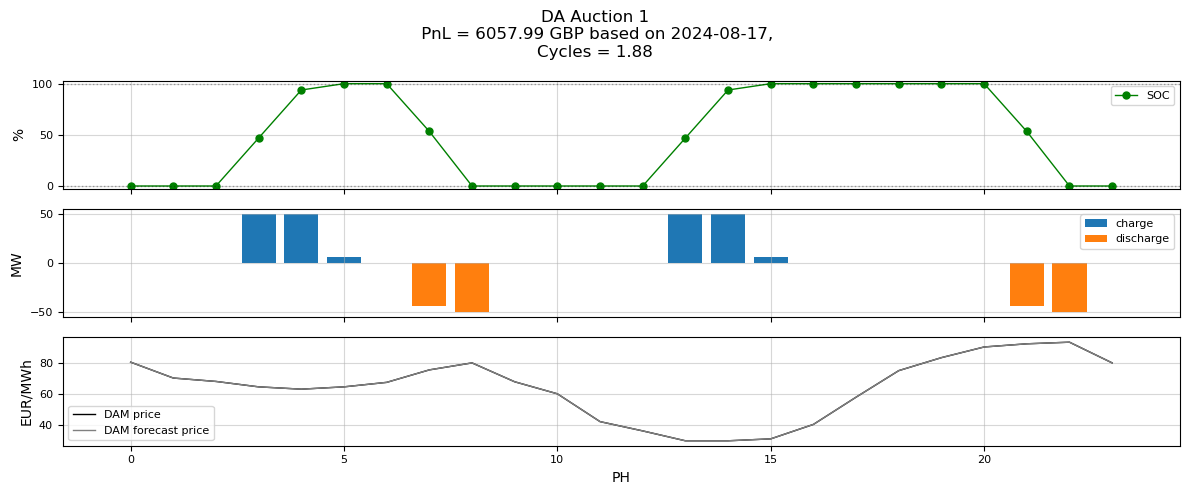

      del_date ref_date   pnl_da
18  2024-08-17     None  6057.99


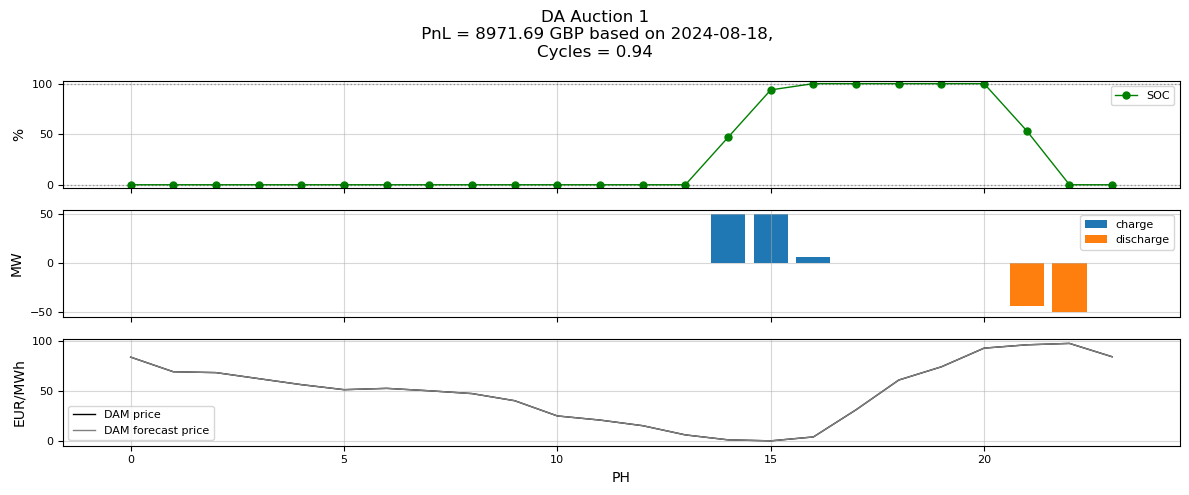

      del_date ref_date   pnl_da
19  2024-08-18     None  8971.69


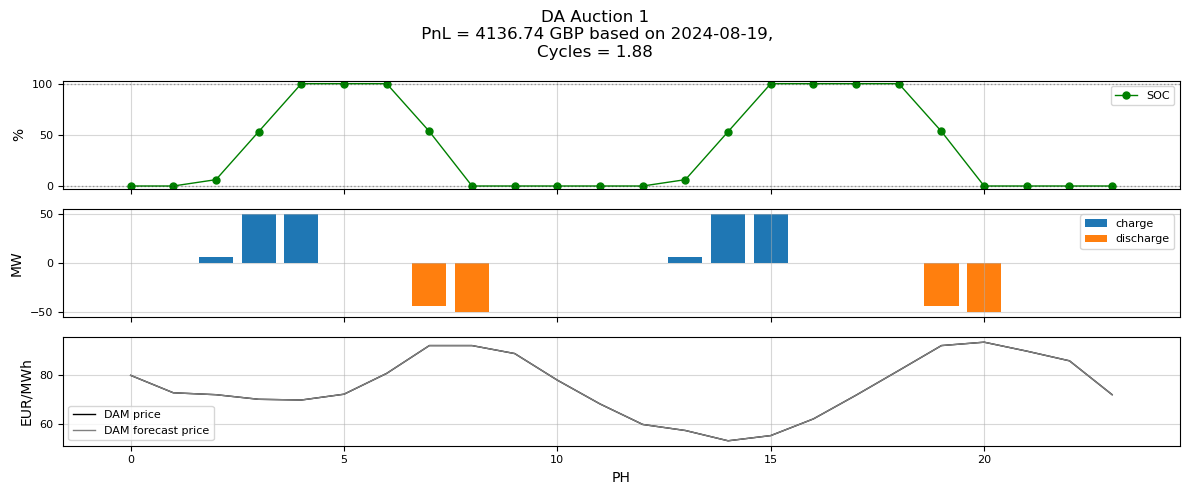

      del_date ref_date   pnl_da
20  2024-08-19     None  4136.74


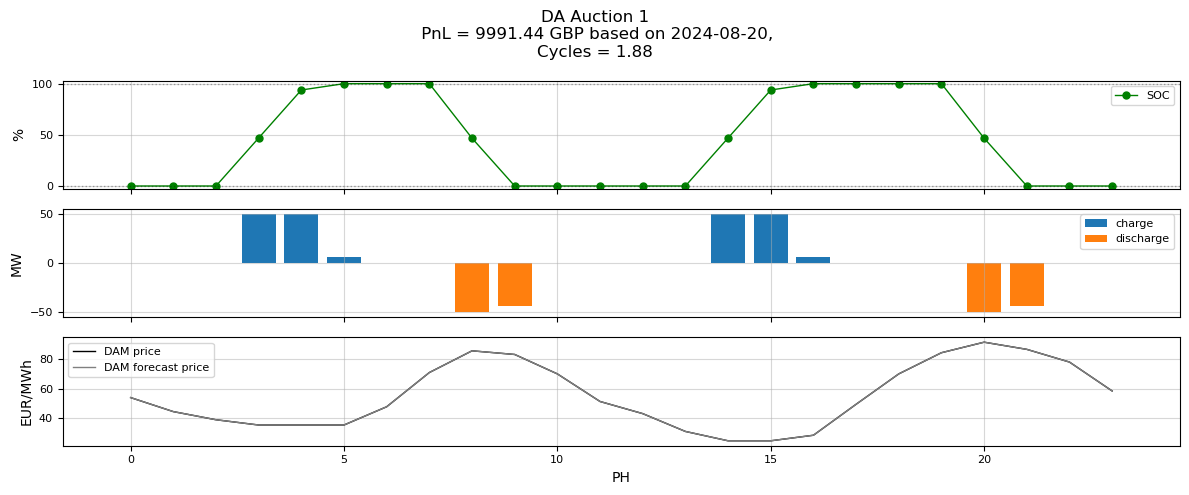

      del_date ref_date   pnl_da
21  2024-08-20     None  9991.44


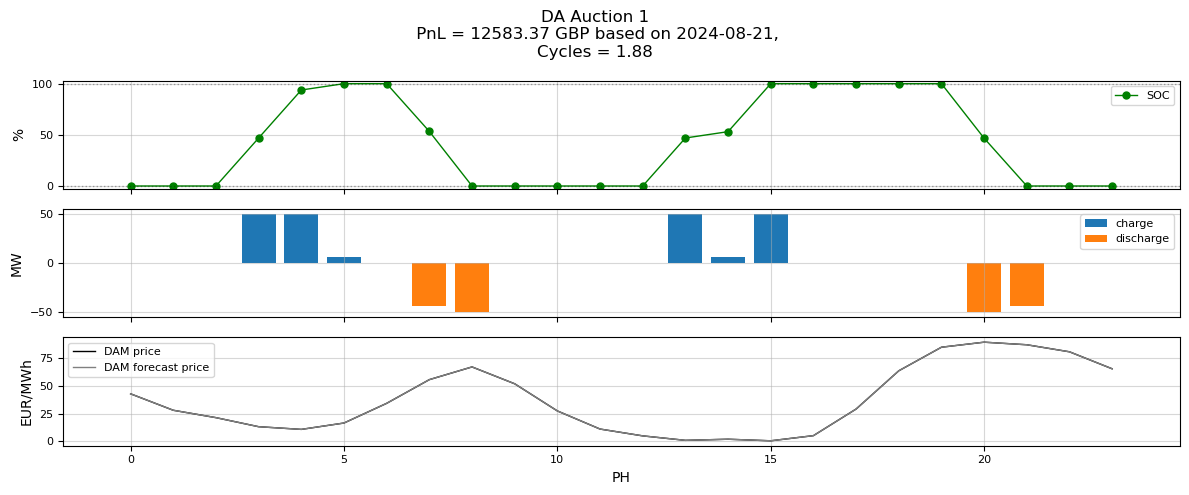

      del_date ref_date    pnl_da
22  2024-08-21     None  12583.37


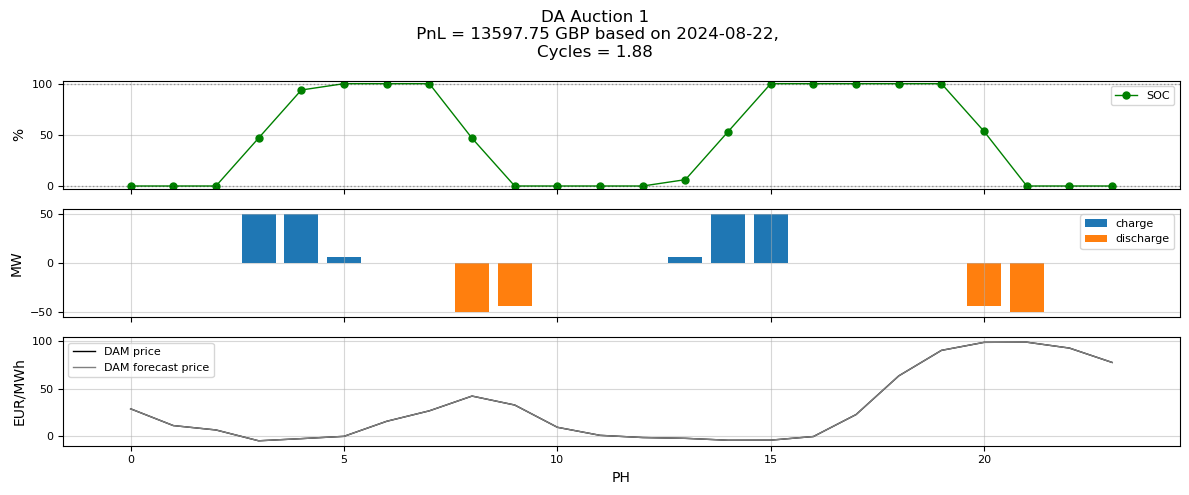

      del_date ref_date    pnl_da
23  2024-08-22     None  13597.75


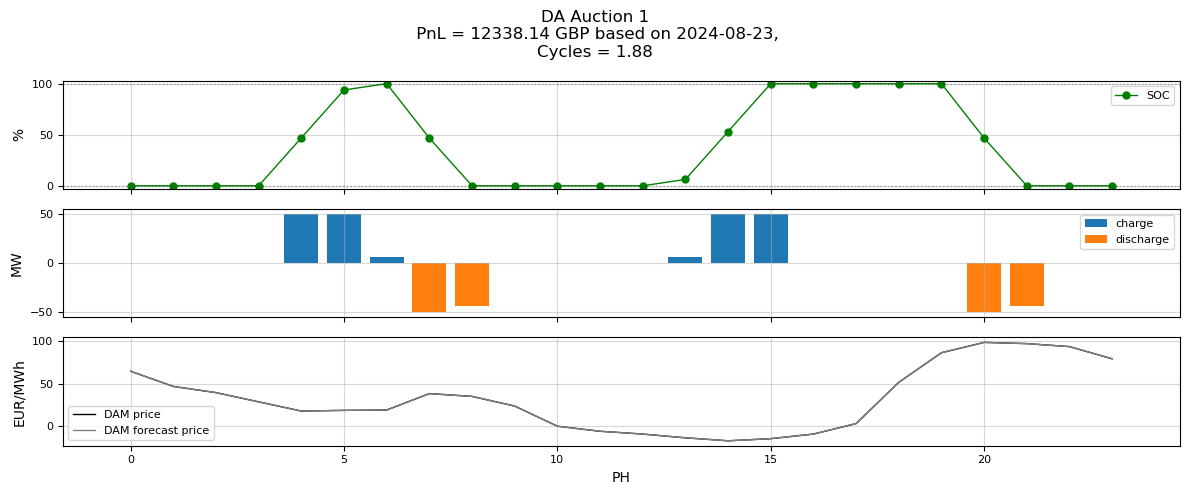

      del_date ref_date    pnl_da
24  2024-08-23     None  12338.14


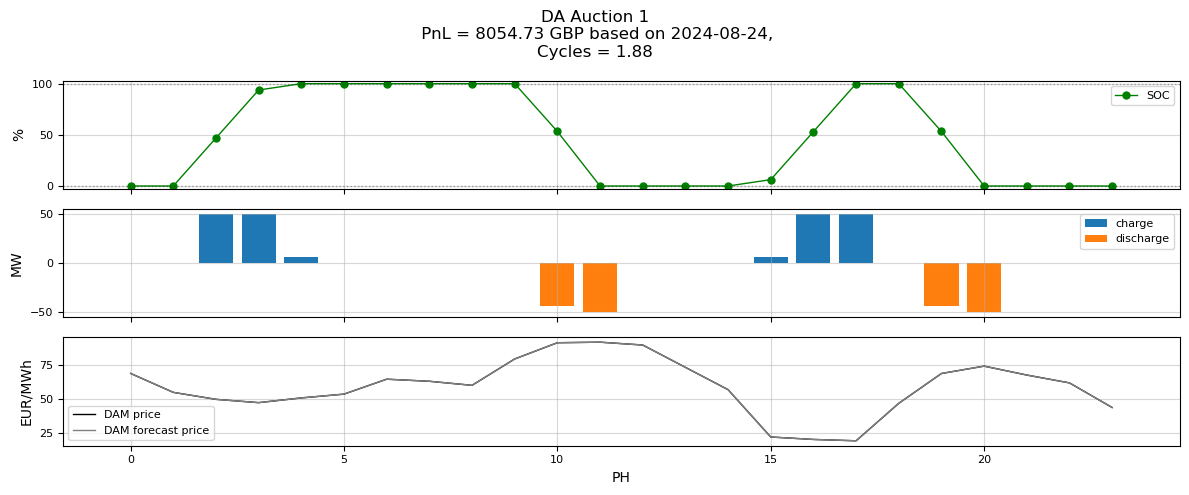

      del_date ref_date   pnl_da
25  2024-08-24     None  8054.73


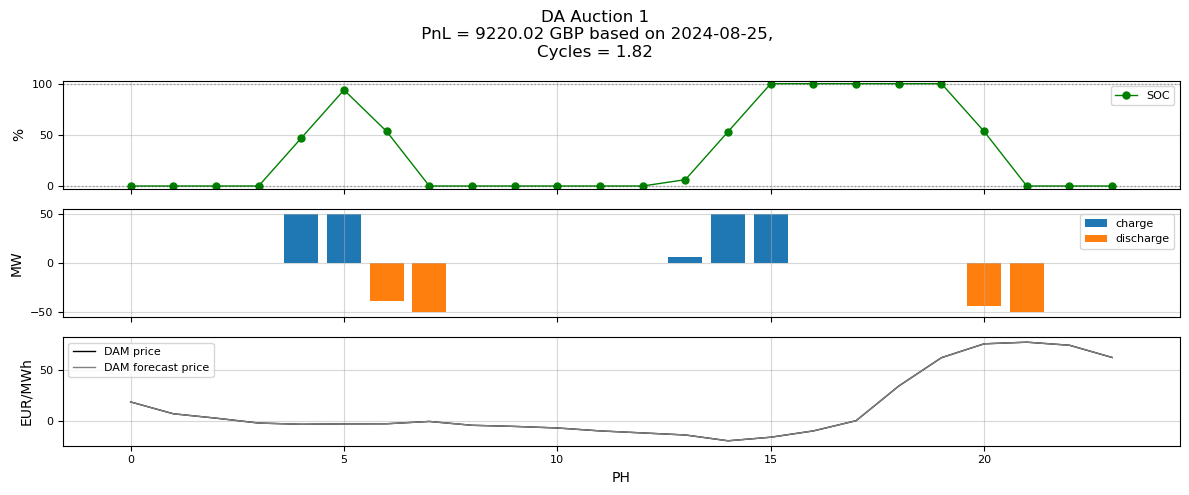

      del_date ref_date   pnl_da
26  2024-08-25     None  9220.02


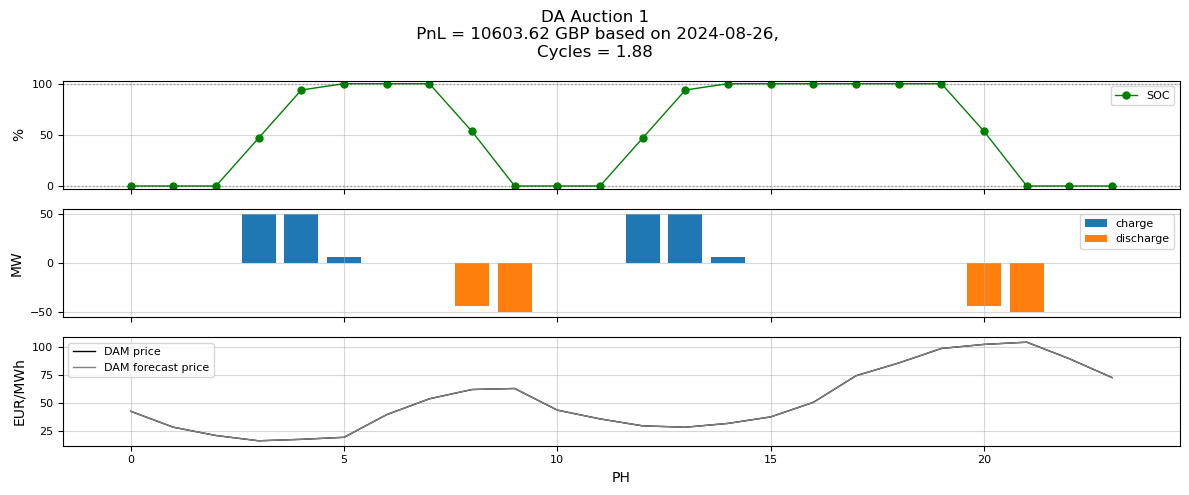

      del_date ref_date    pnl_da
27  2024-08-26     None  10603.62


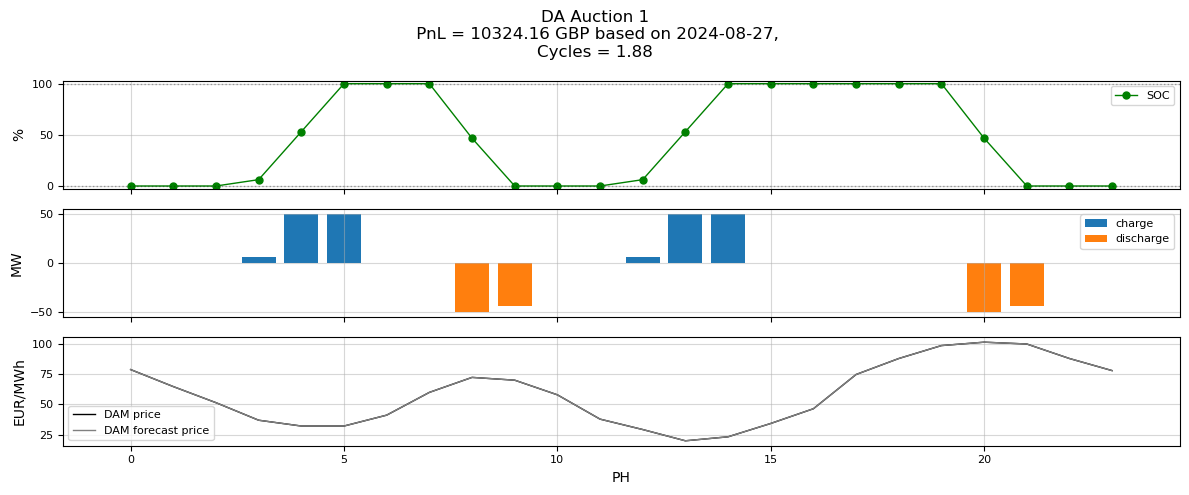

      del_date ref_date    pnl_da
28  2024-08-27     None  10324.16


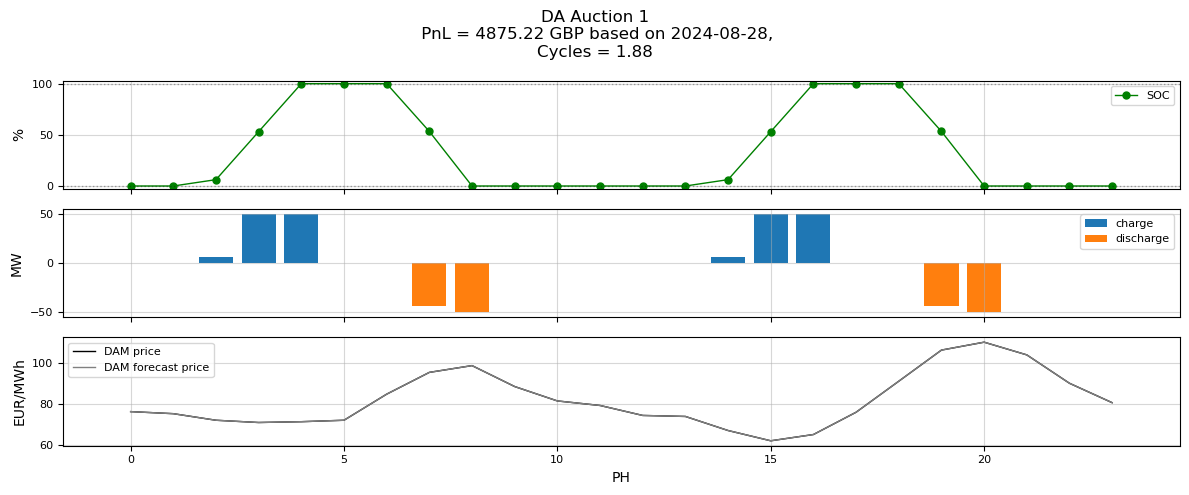

      del_date ref_date   pnl_da
29  2024-08-28     None  4875.22


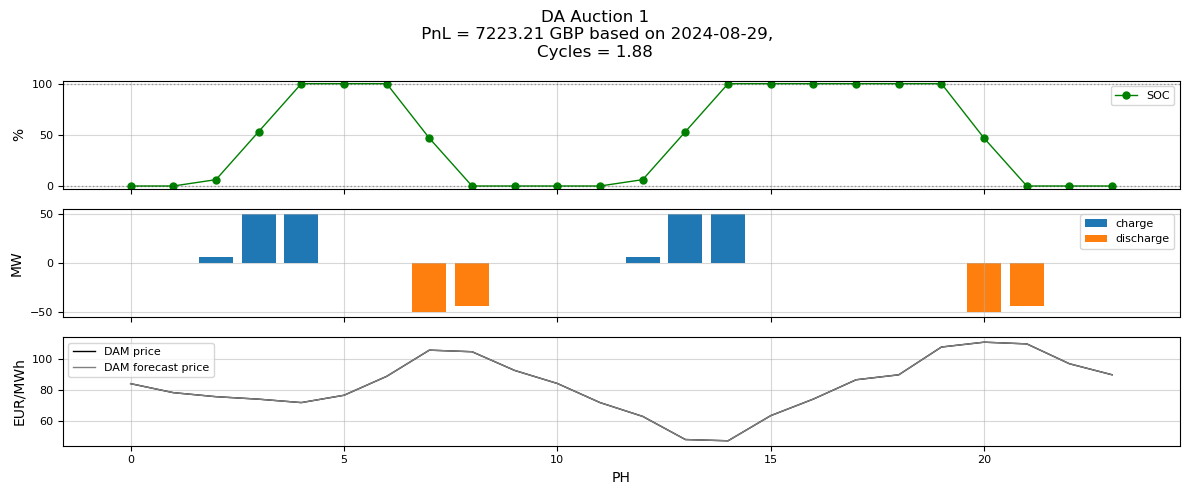

      del_date ref_date   pnl_da
30  2024-08-29     None  7223.21


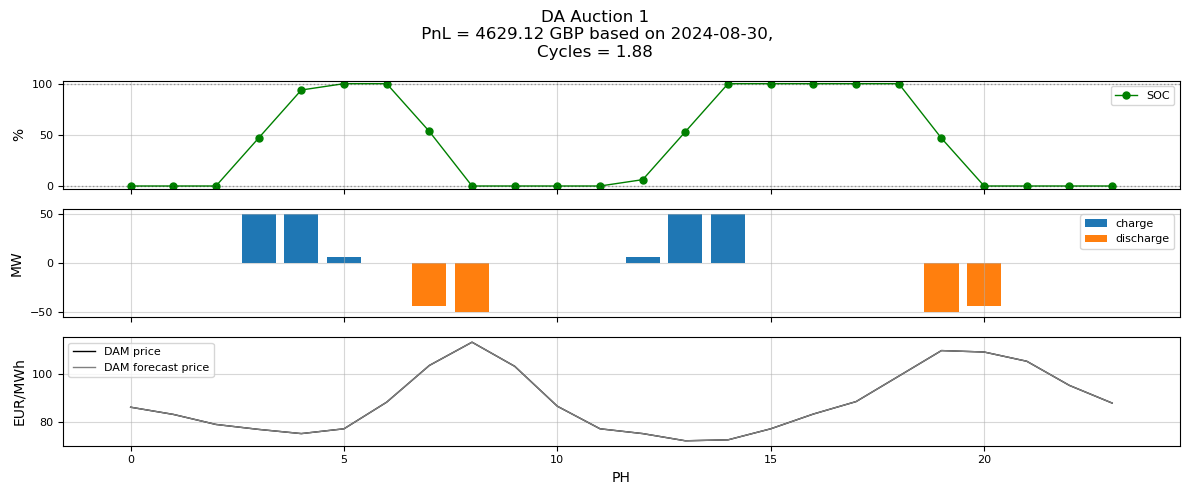

      del_date ref_date   pnl_da
31  2024-08-30     None  4629.12


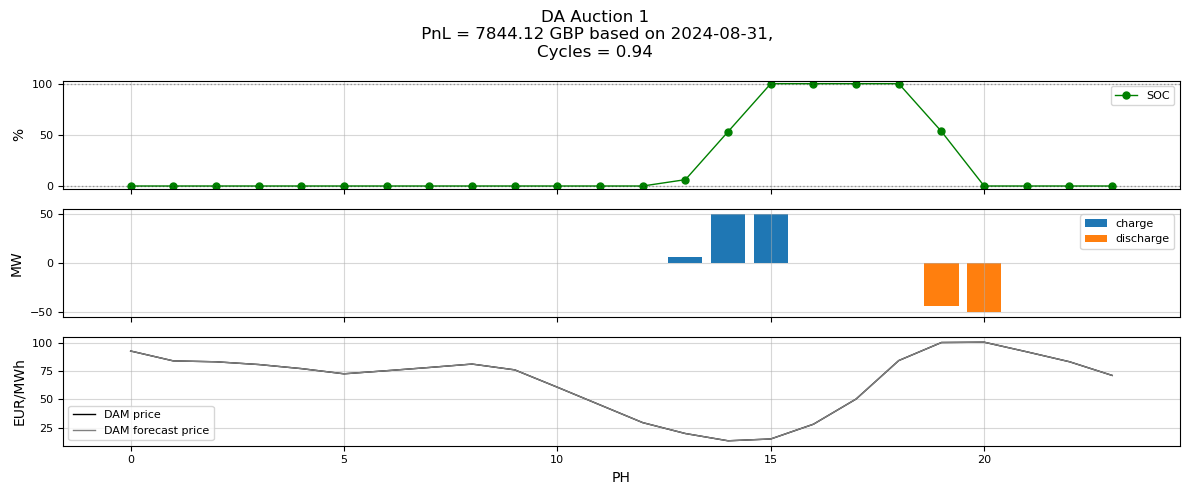

      del_date ref_date   pnl_da
32  2024-08-31     None  7844.12


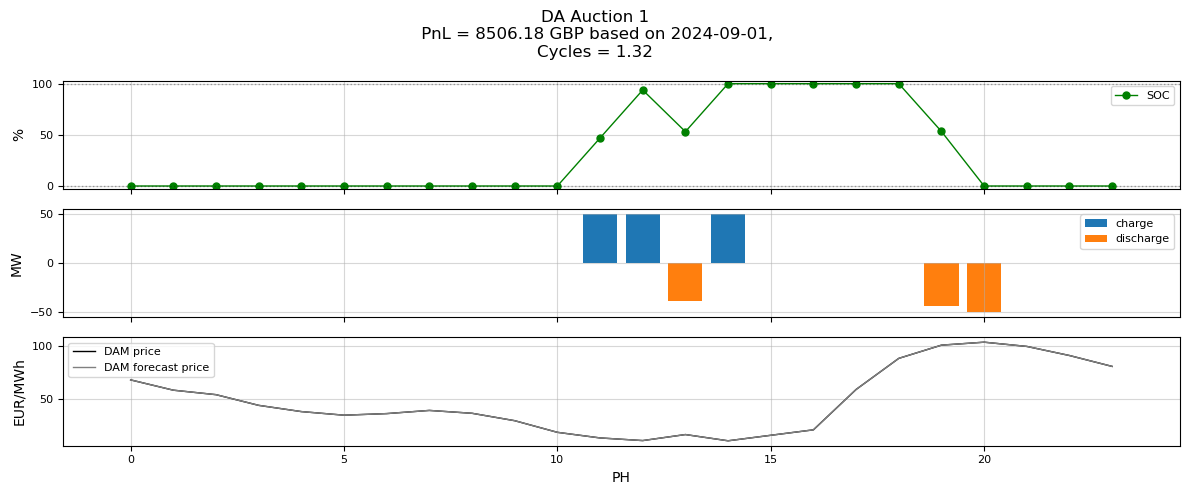

      del_date ref_date   pnl_da
33  2024-09-01     None  8506.18


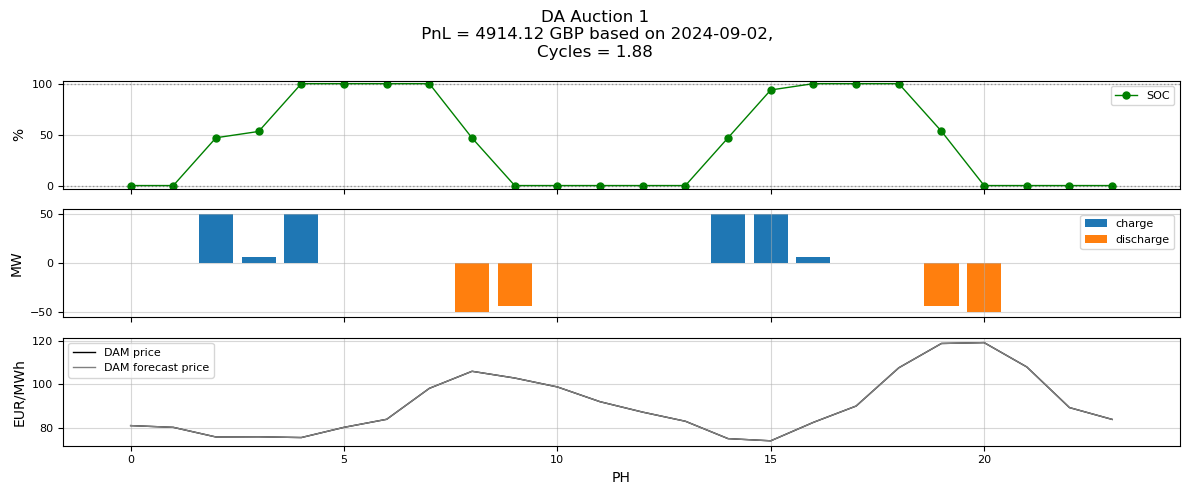

      del_date ref_date   pnl_da
34  2024-09-02     None  4914.12


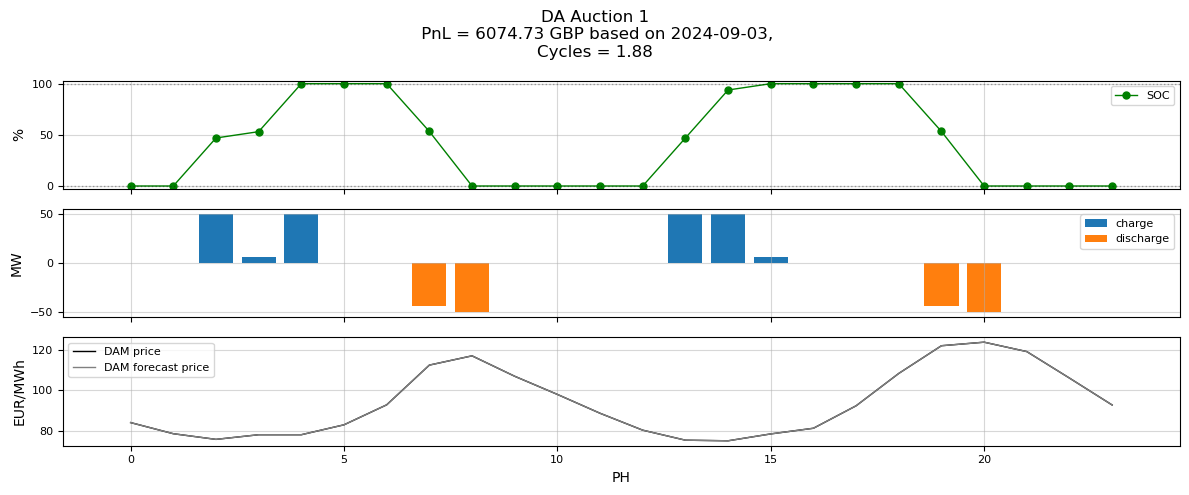

      del_date ref_date   pnl_da
35  2024-09-03     None  6074.73


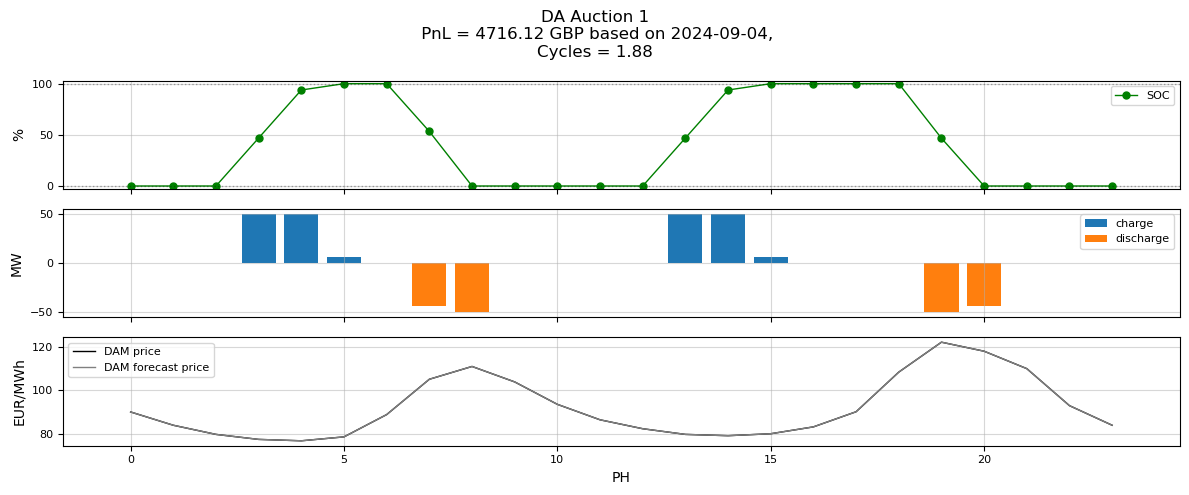

      del_date ref_date   pnl_da
36  2024-09-04     None  4716.12


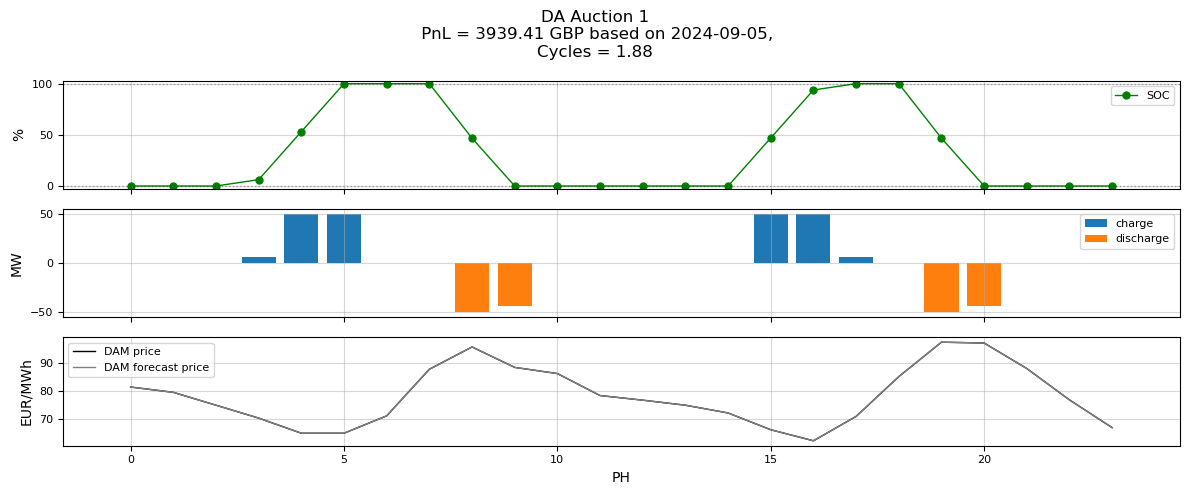

      del_date ref_date   pnl_da
37  2024-09-05     None  3939.41


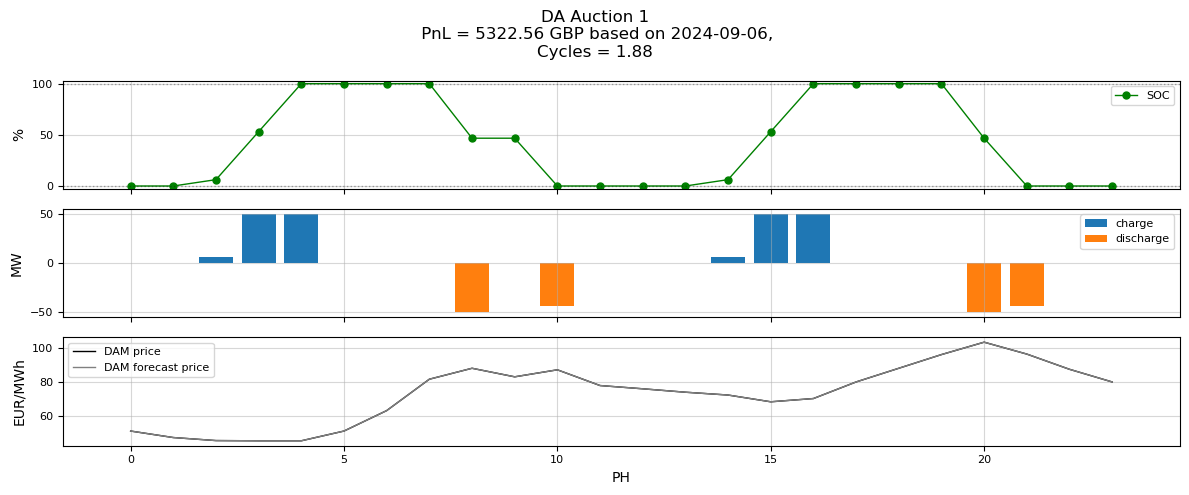

      del_date ref_date   pnl_da
38  2024-09-06     None  5322.56


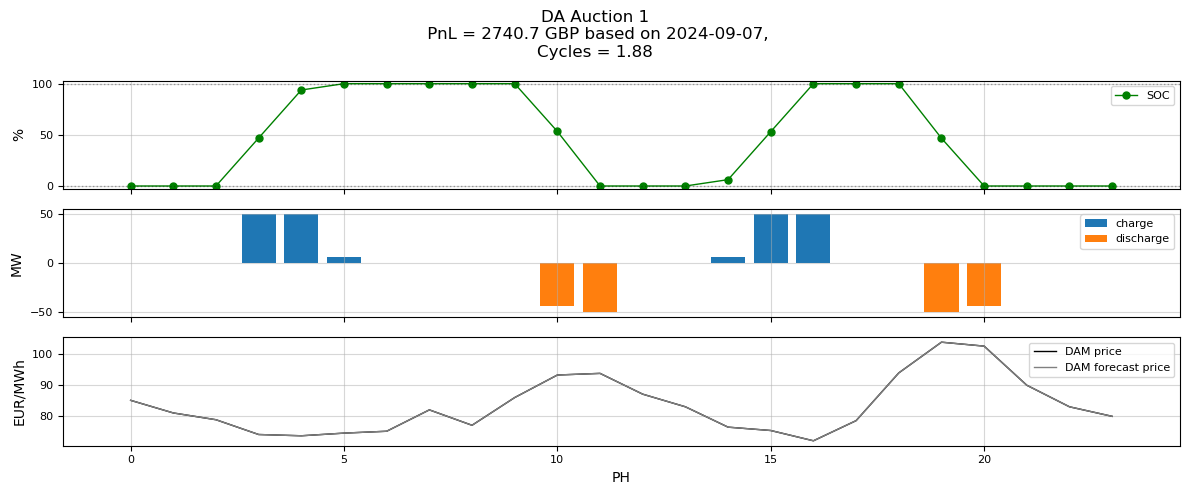

      del_date ref_date  pnl_da
39  2024-09-07     None  2740.7


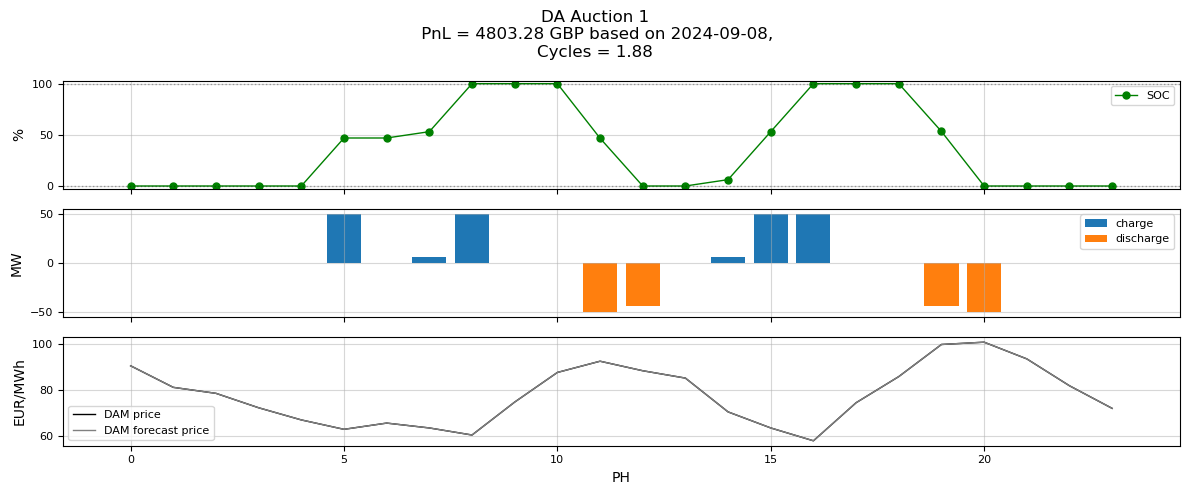

      del_date ref_date   pnl_da
40  2024-09-08     None  4803.28


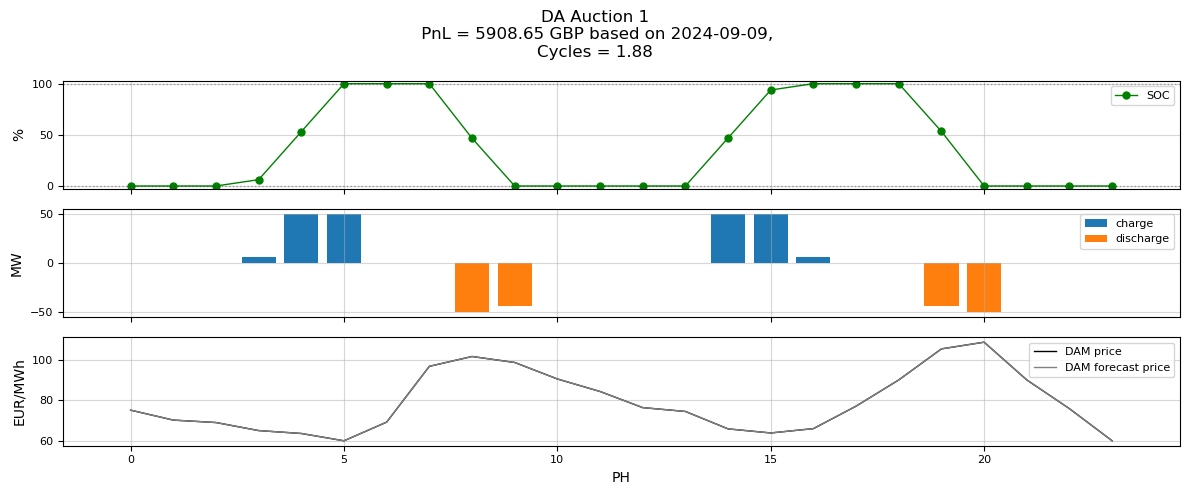

      del_date ref_date   pnl_da
41  2024-09-09     None  5908.65


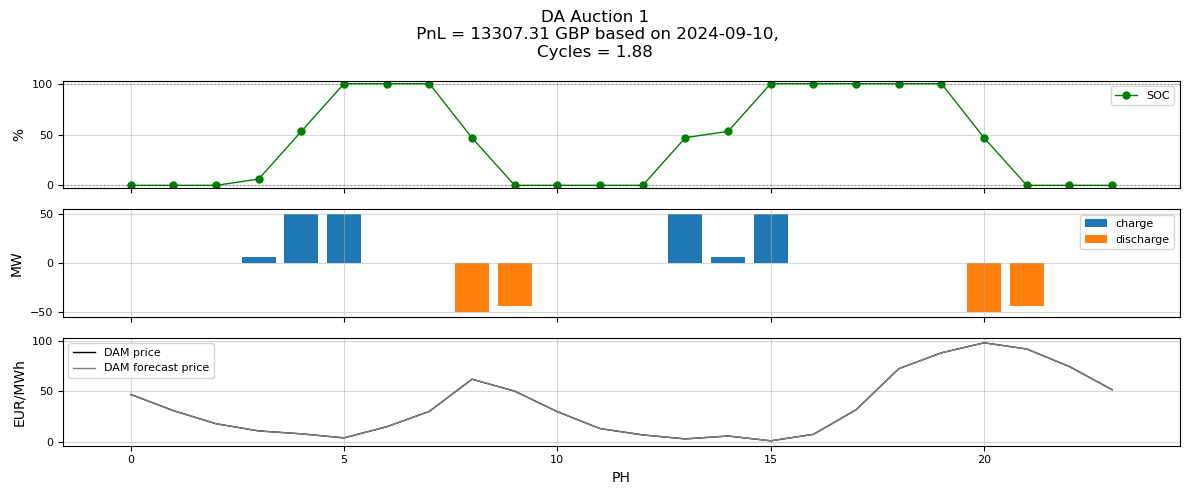

      del_date ref_date    pnl_da
42  2024-09-10     None  13307.31


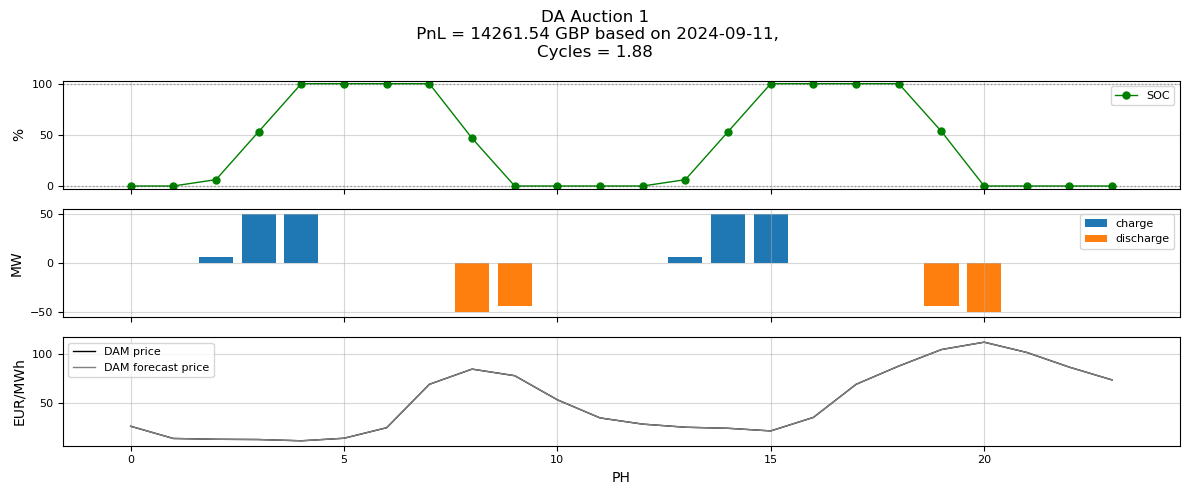

      del_date ref_date    pnl_da
43  2024-09-11     None  14261.54


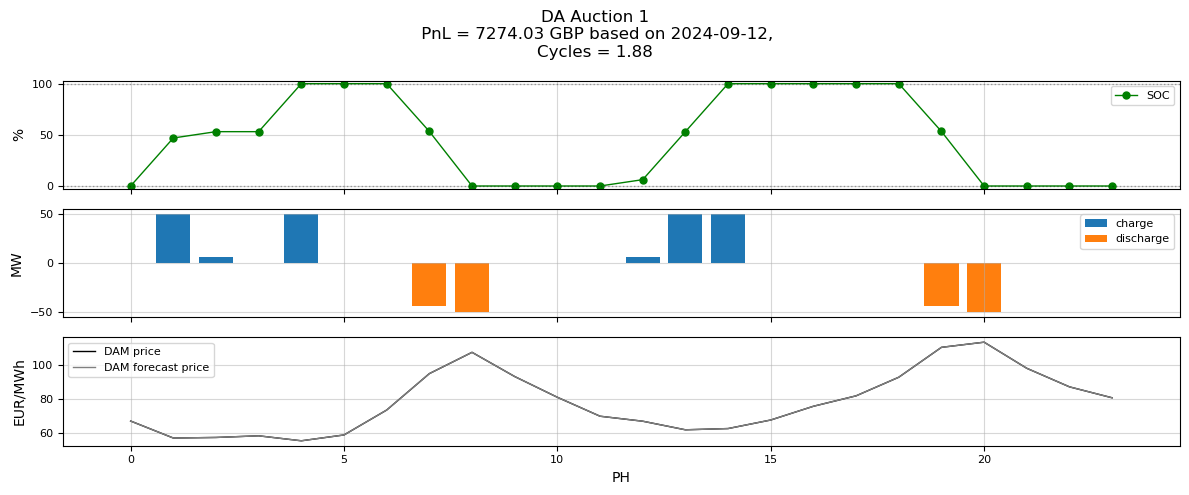

      del_date ref_date   pnl_da
44  2024-09-12     None  7274.03


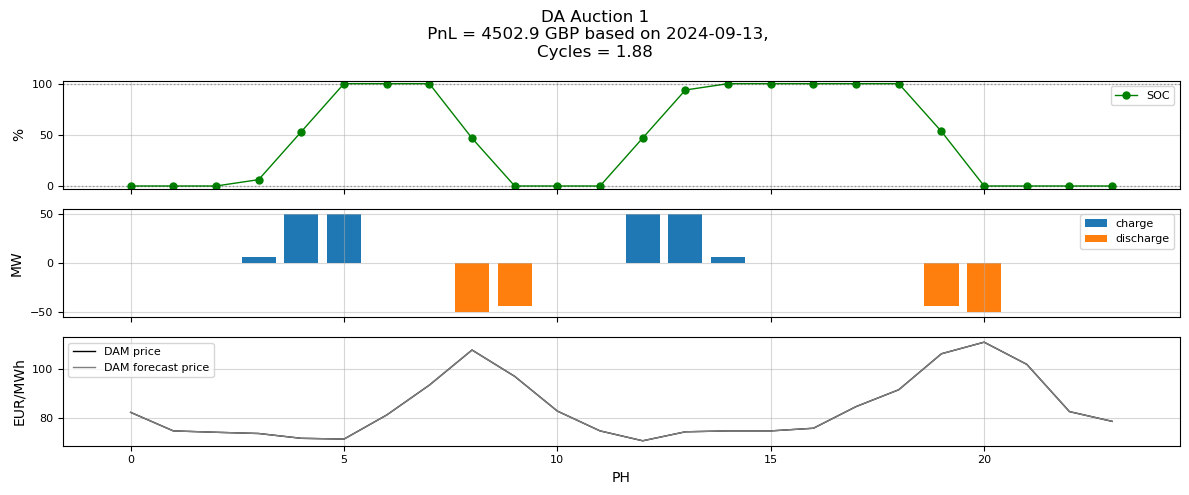

      del_date ref_date  pnl_da
45  2024-09-13     None  4502.9


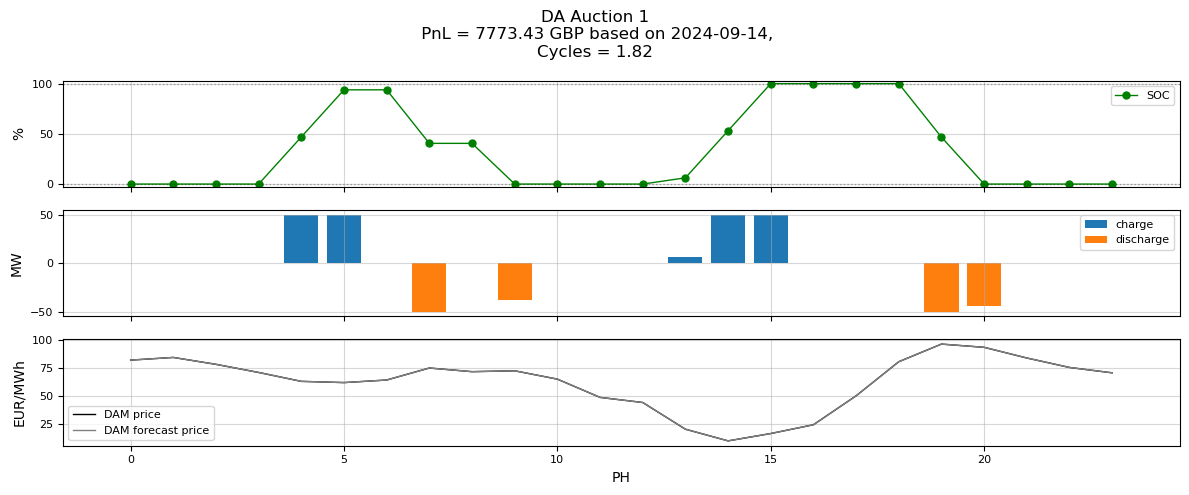

      del_date ref_date   pnl_da
46  2024-09-14     None  7773.43


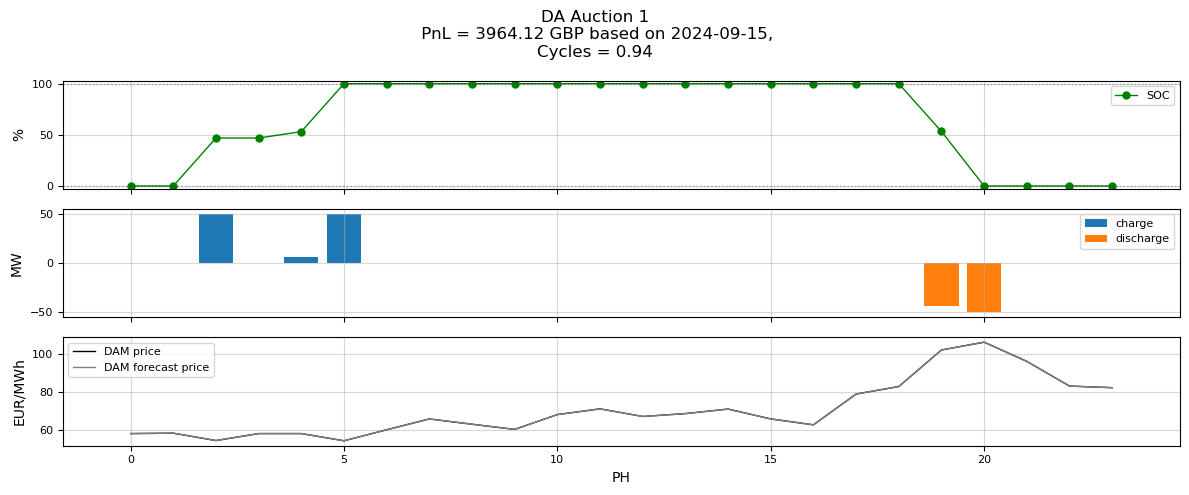

      del_date ref_date   pnl_da
47  2024-09-15     None  3964.12


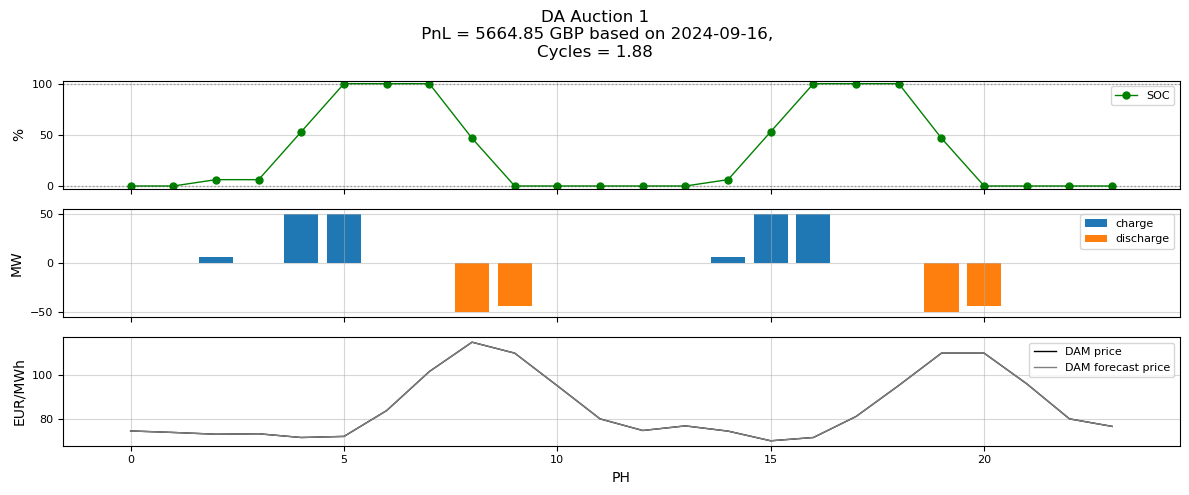

      del_date ref_date   pnl_da
48  2024-09-16     None  5664.85


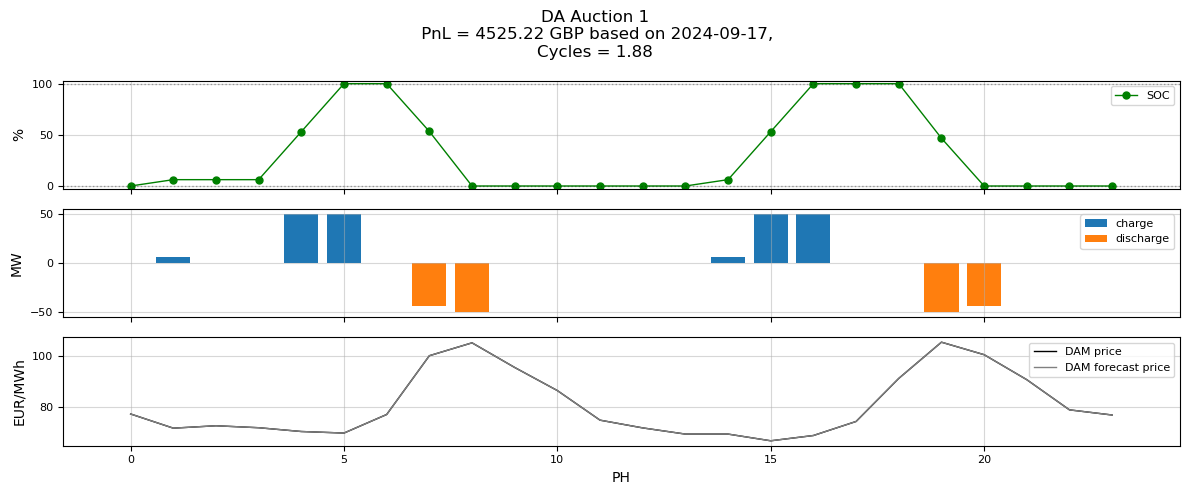

      del_date ref_date   pnl_da
49  2024-09-17     None  4525.22


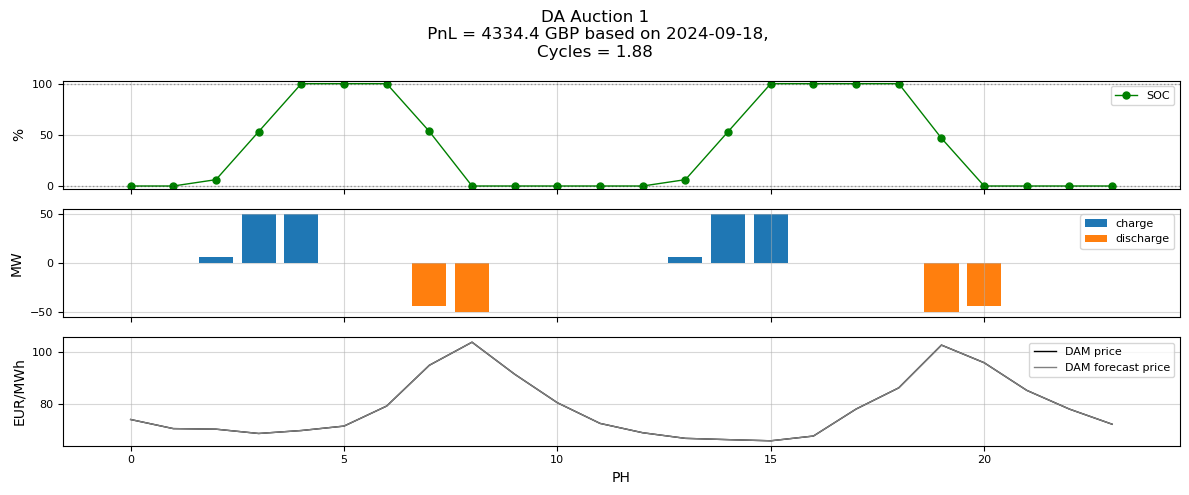

      del_date ref_date  pnl_da
50  2024-09-18     None  4334.4


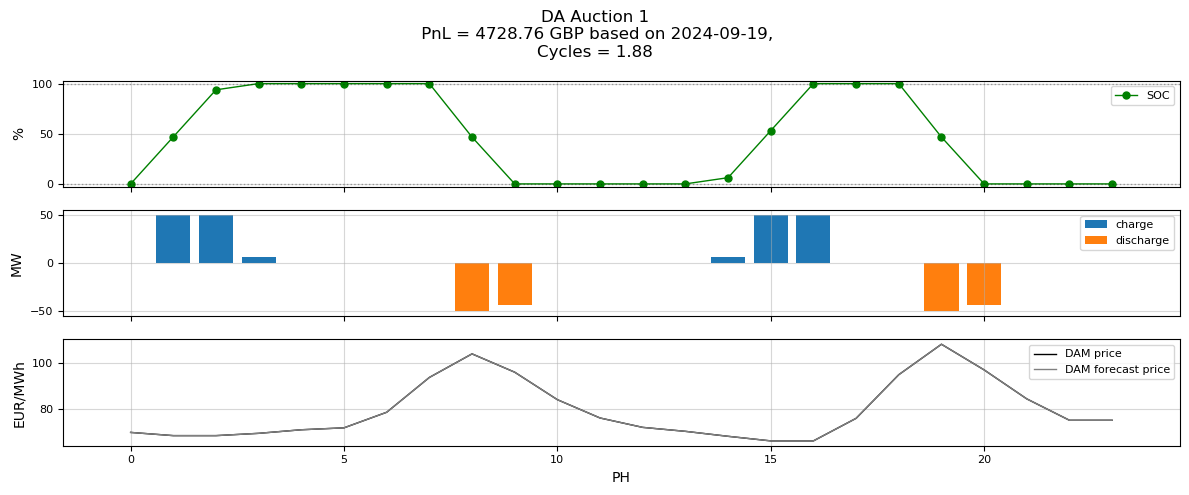

      del_date ref_date   pnl_da
51  2024-09-19     None  4728.76


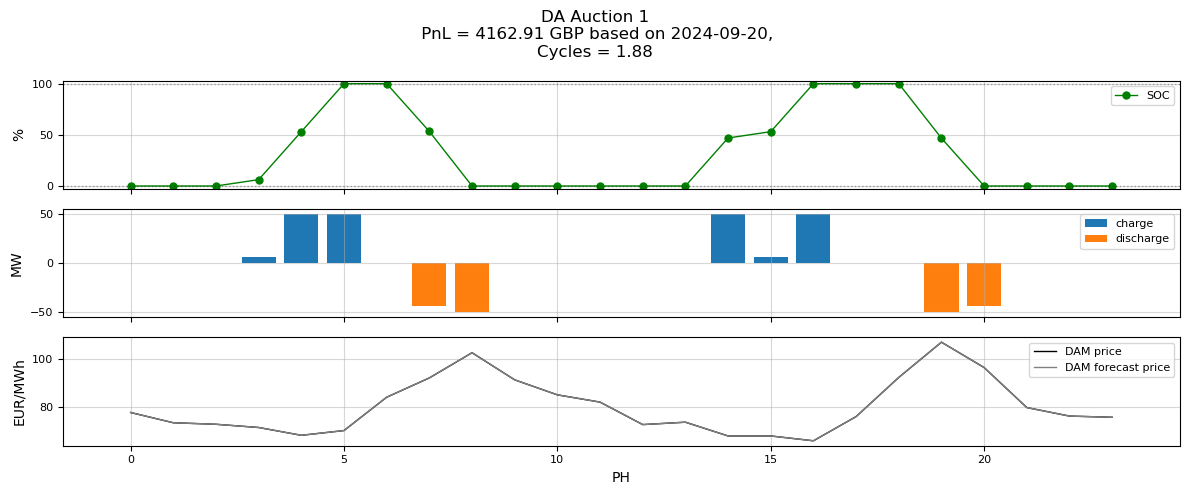

      del_date ref_date   pnl_da
52  2024-09-20     None  4162.91


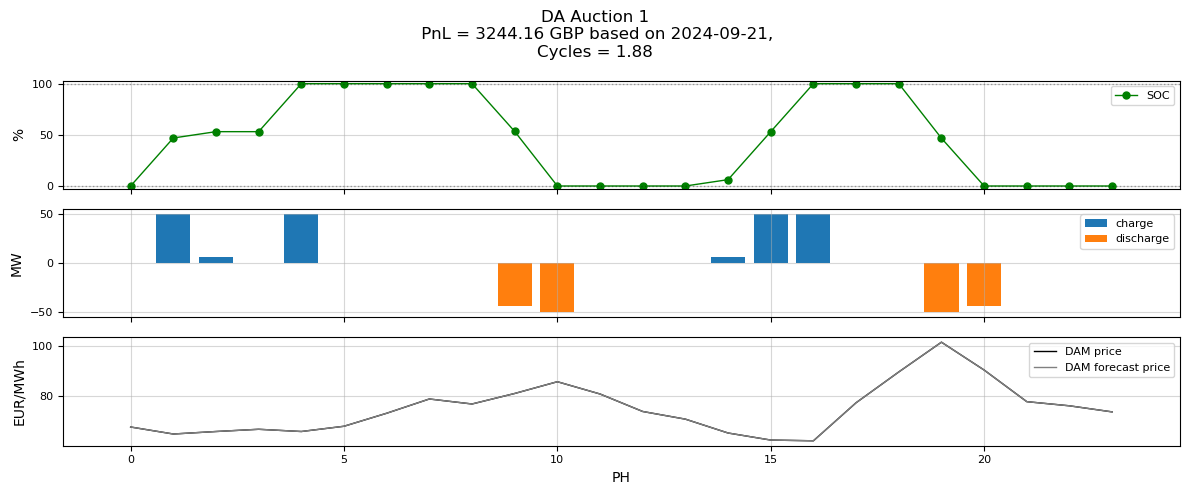

      del_date ref_date   pnl_da
53  2024-09-21     None  3244.16


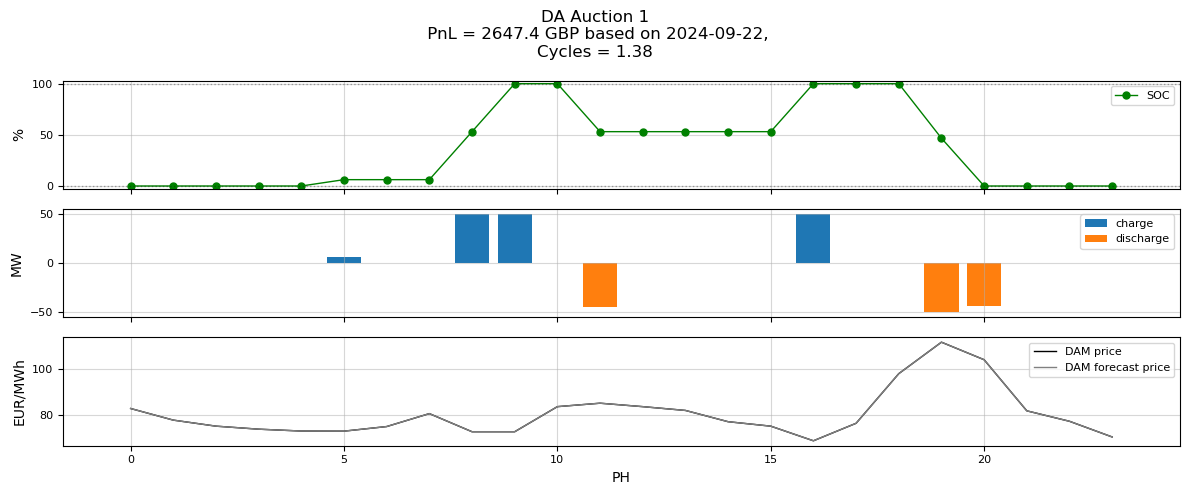

      del_date ref_date  pnl_da
54  2024-09-22     None  2647.4


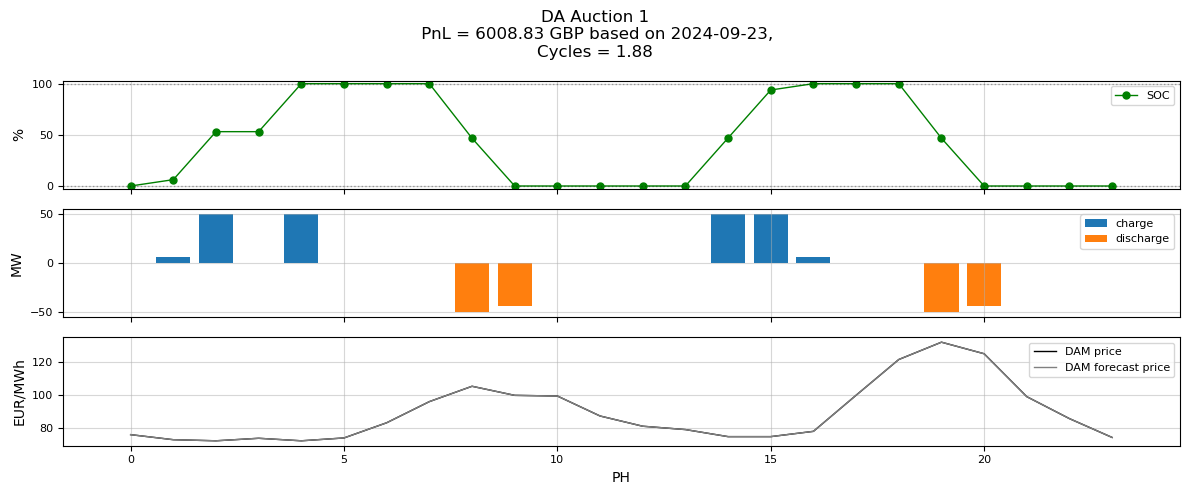

      del_date ref_date   pnl_da
55  2024-09-23     None  6008.83


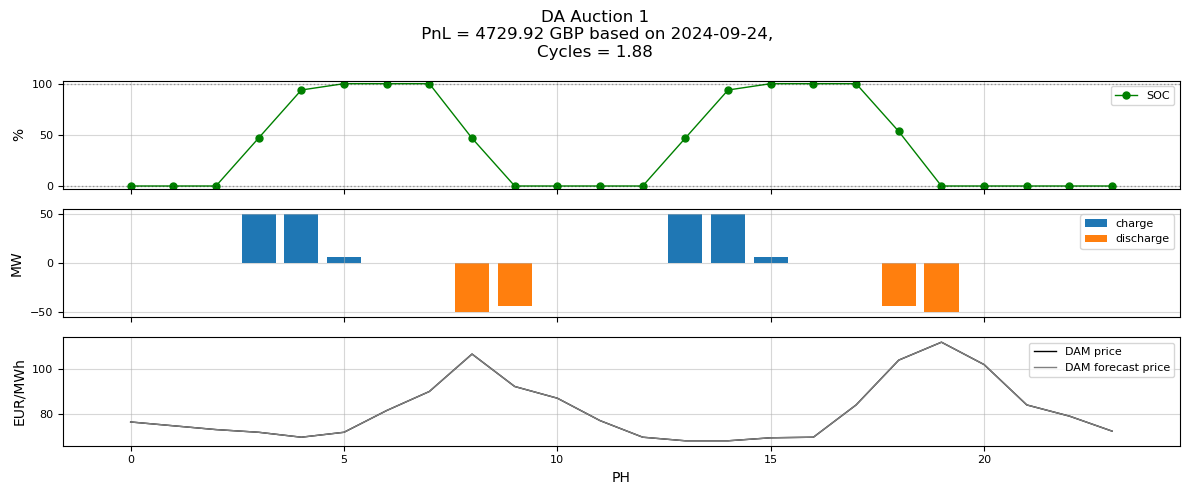

      del_date ref_date   pnl_da
56  2024-09-24     None  4729.92


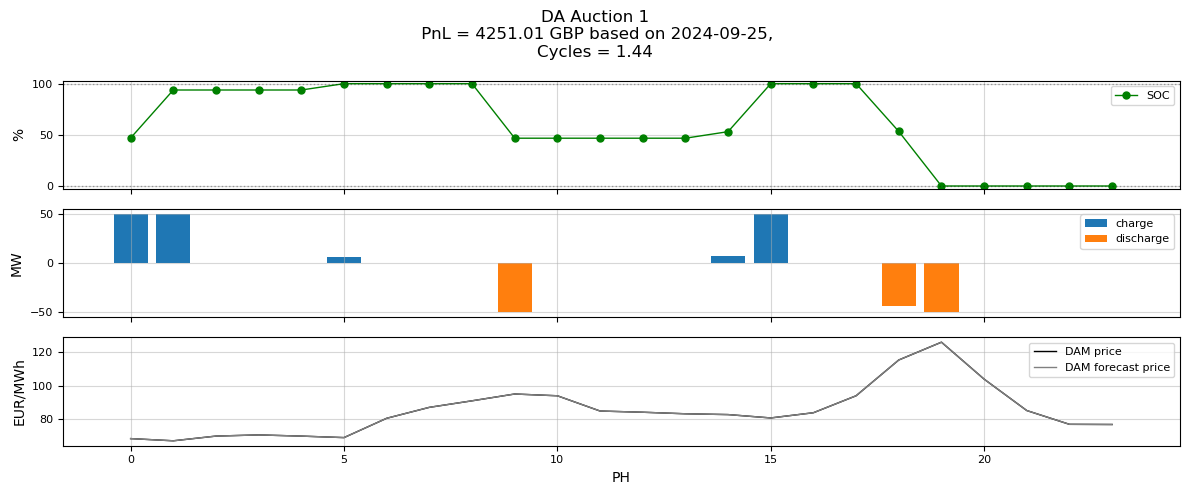

      del_date ref_date   pnl_da
57  2024-09-25     None  4251.01


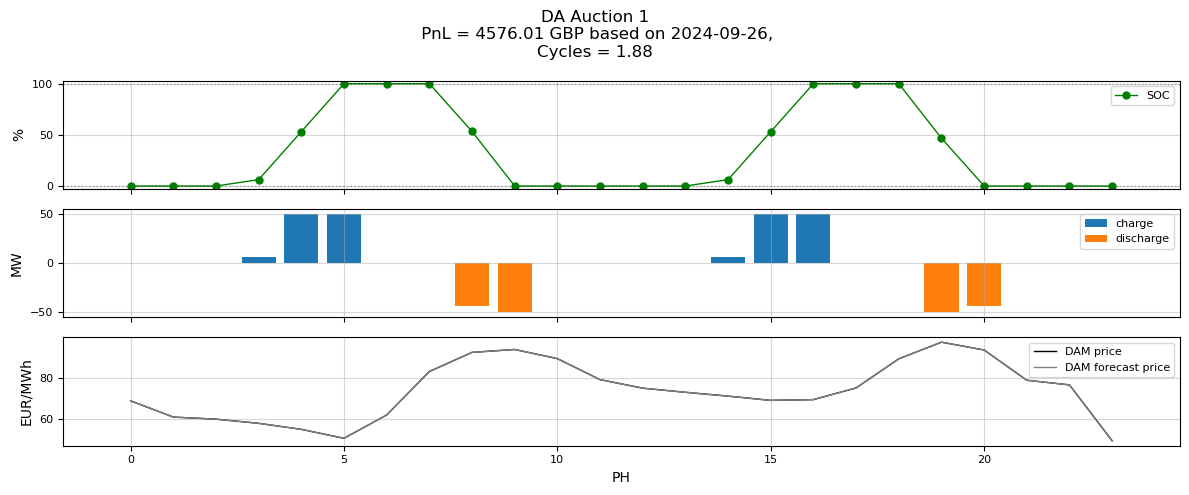

      del_date ref_date   pnl_da
58  2024-09-26     None  4576.01


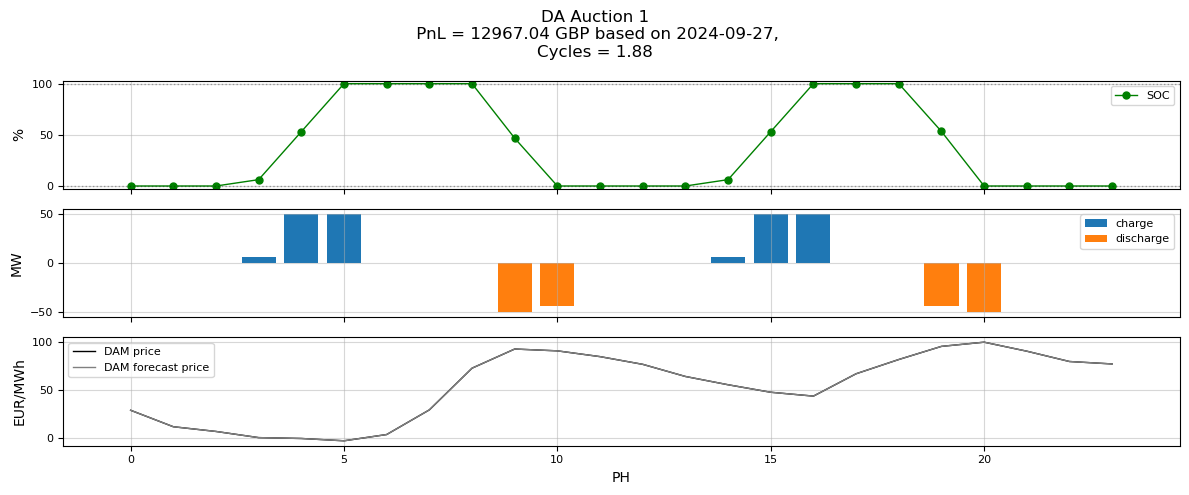

      del_date ref_date    pnl_da
59  2024-09-27     None  12967.04


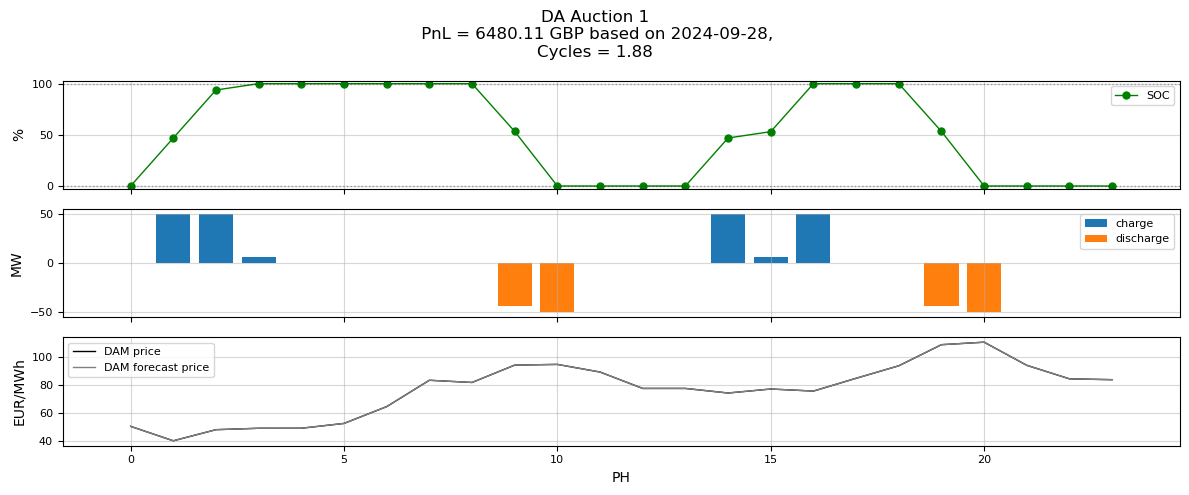

      del_date ref_date   pnl_da
60  2024-09-28     None  6480.11


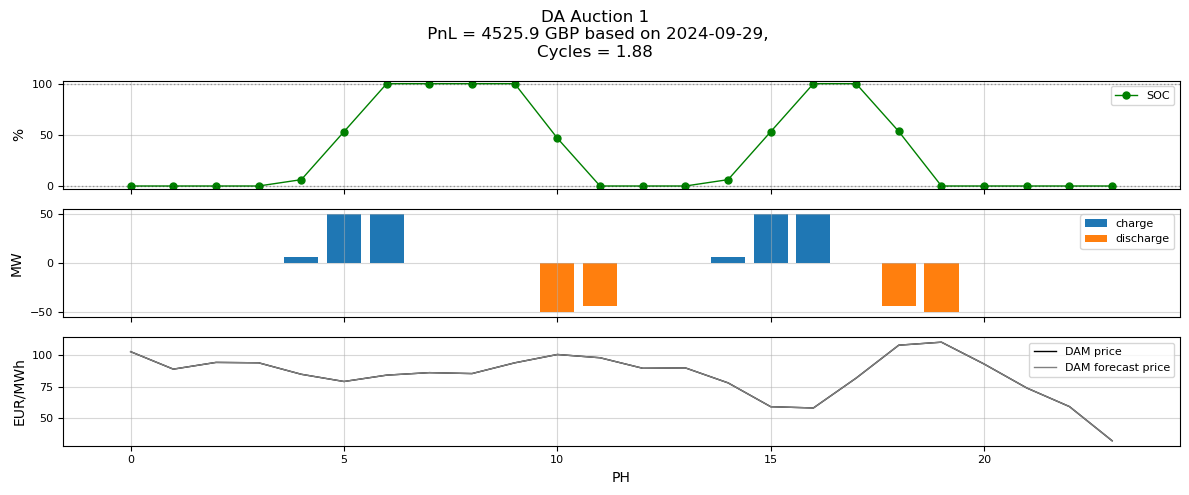

      del_date ref_date  pnl_da
61  2024-09-29     None  4525.9


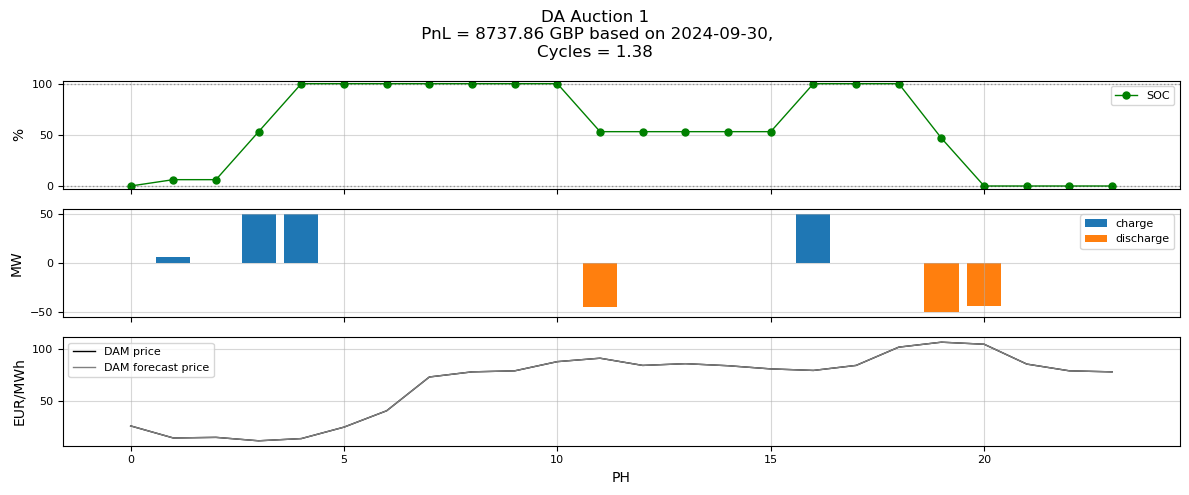

      del_date ref_date   pnl_da
62  2024-09-30     None  8737.86


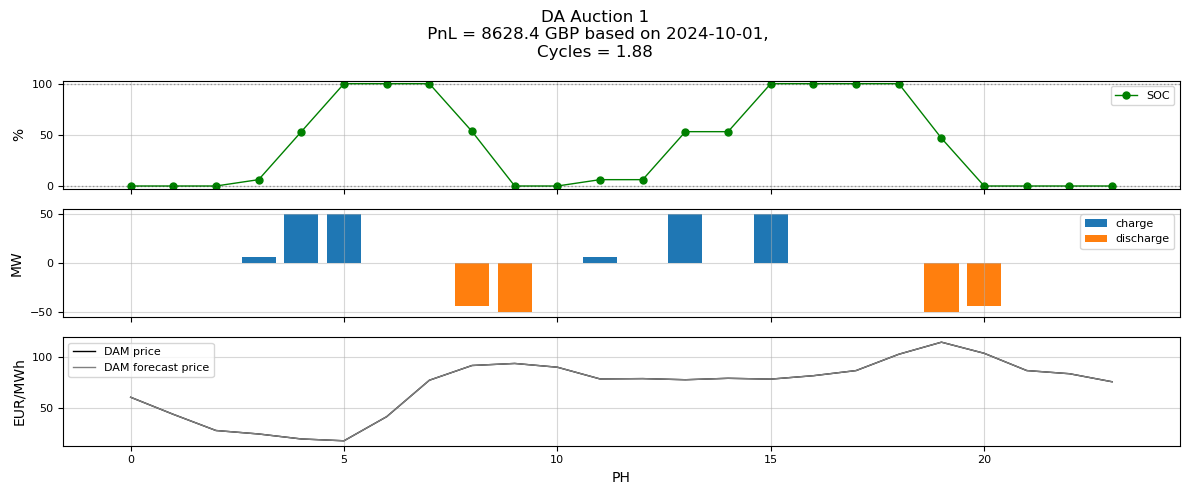

      del_date ref_date  pnl_da
63  2024-10-01     None  8628.4


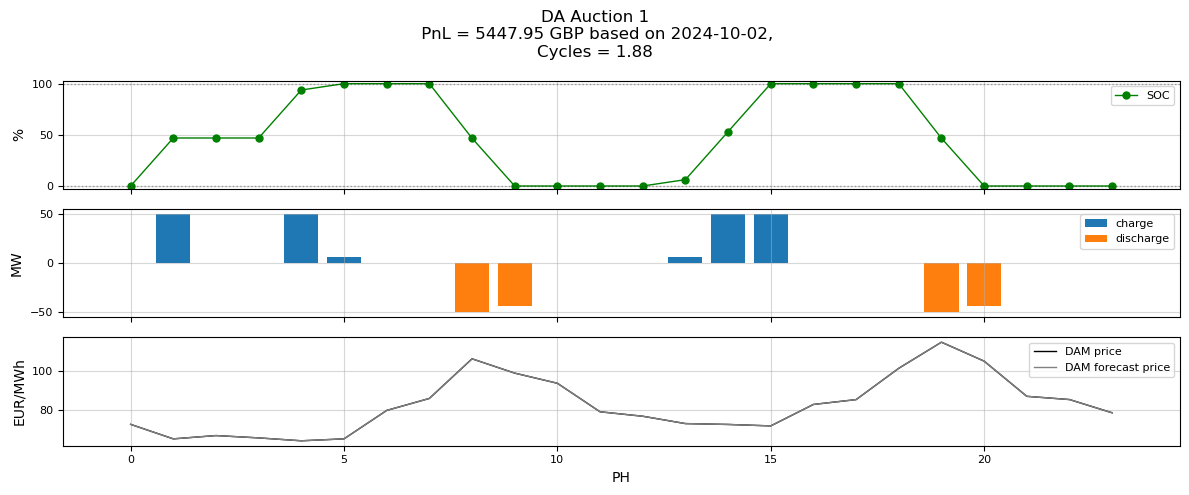

      del_date ref_date   pnl_da
64  2024-10-02     None  5447.95


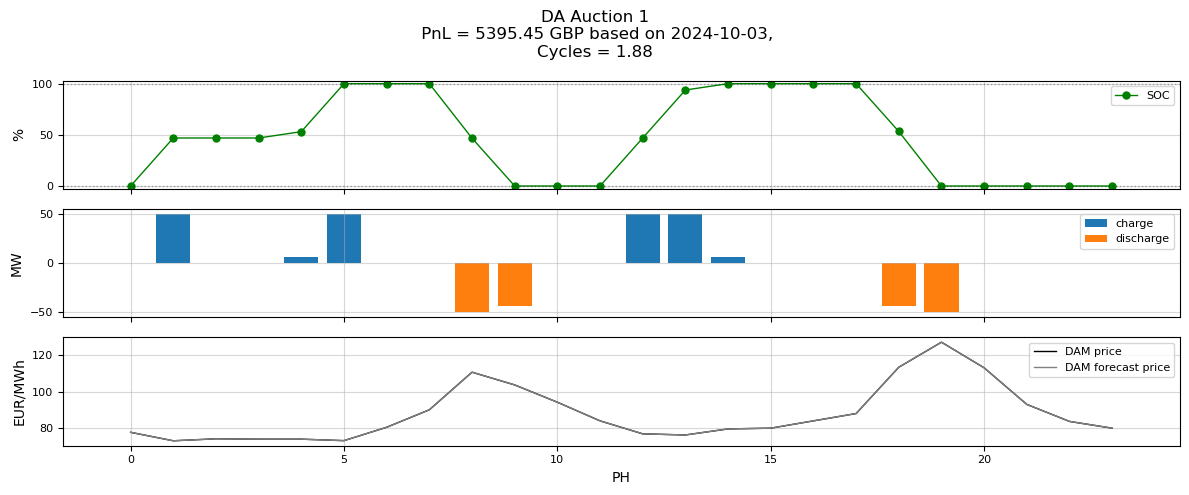

      del_date ref_date   pnl_da
65  2024-10-03     None  5395.45


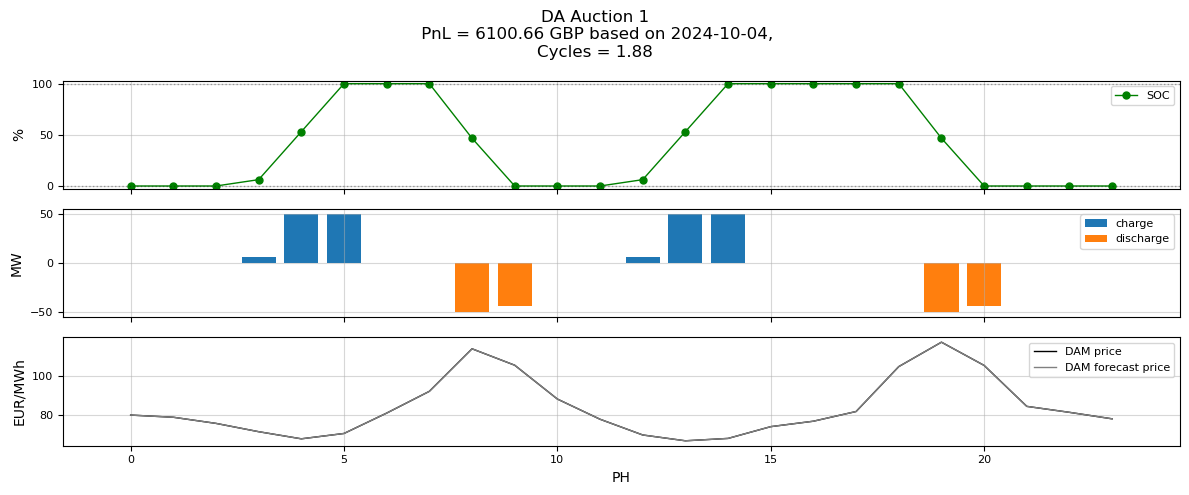

      del_date ref_date   pnl_da
66  2024-10-04     None  6100.66


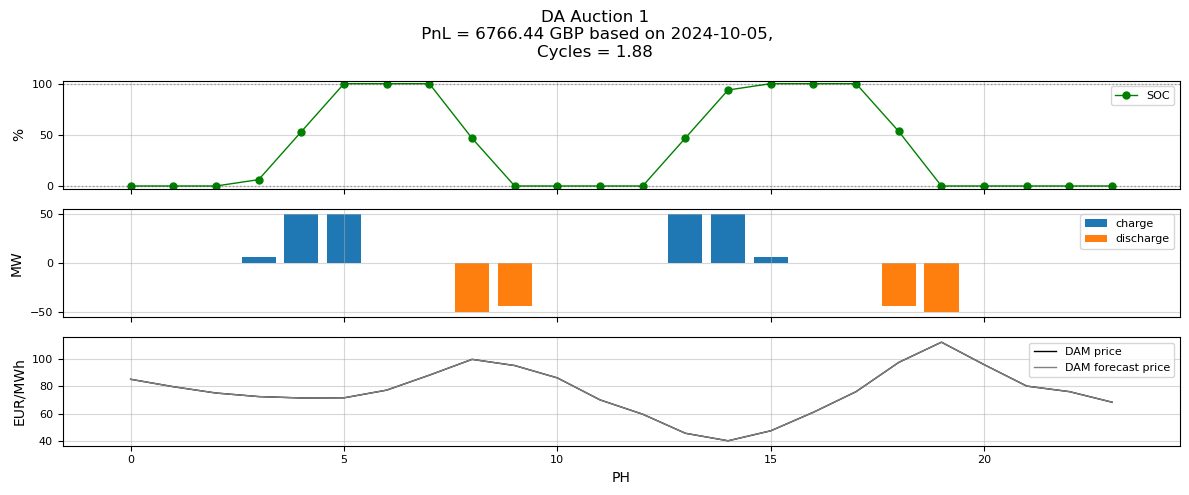

      del_date ref_date   pnl_da
67  2024-10-05     None  6766.44


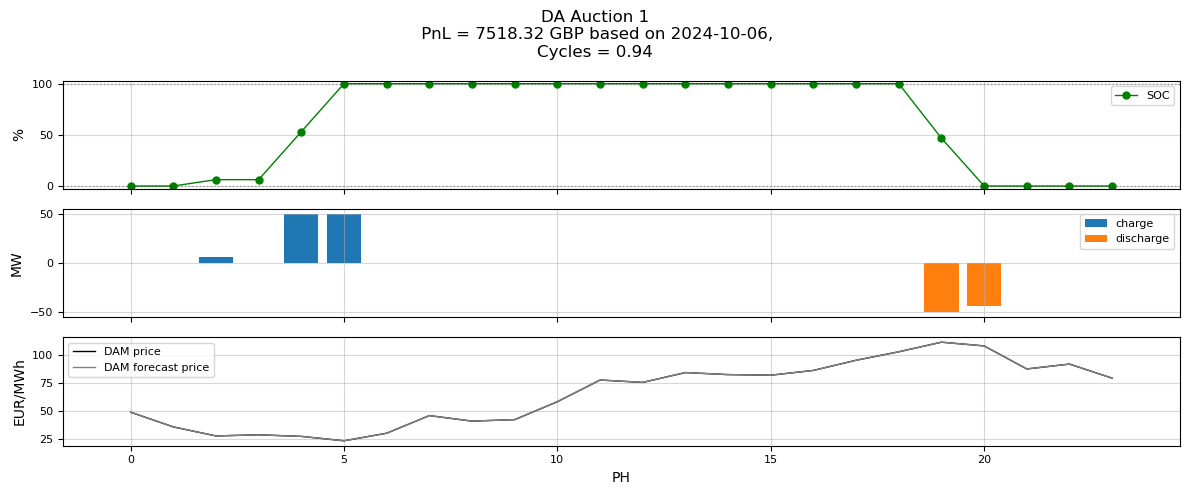

      del_date ref_date   pnl_da
68  2024-10-06     None  7518.32


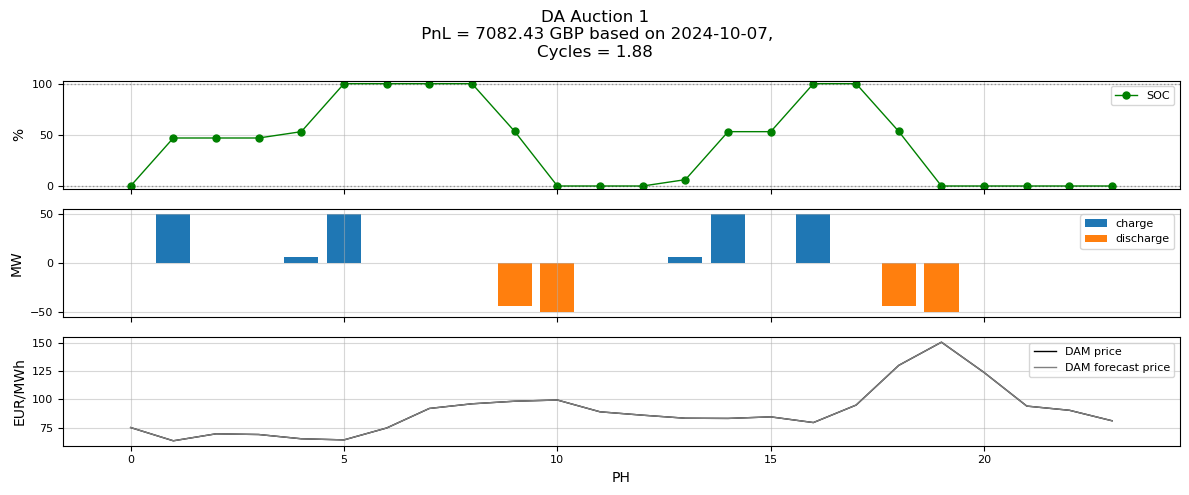

      del_date ref_date   pnl_da
69  2024-10-07     None  7082.43


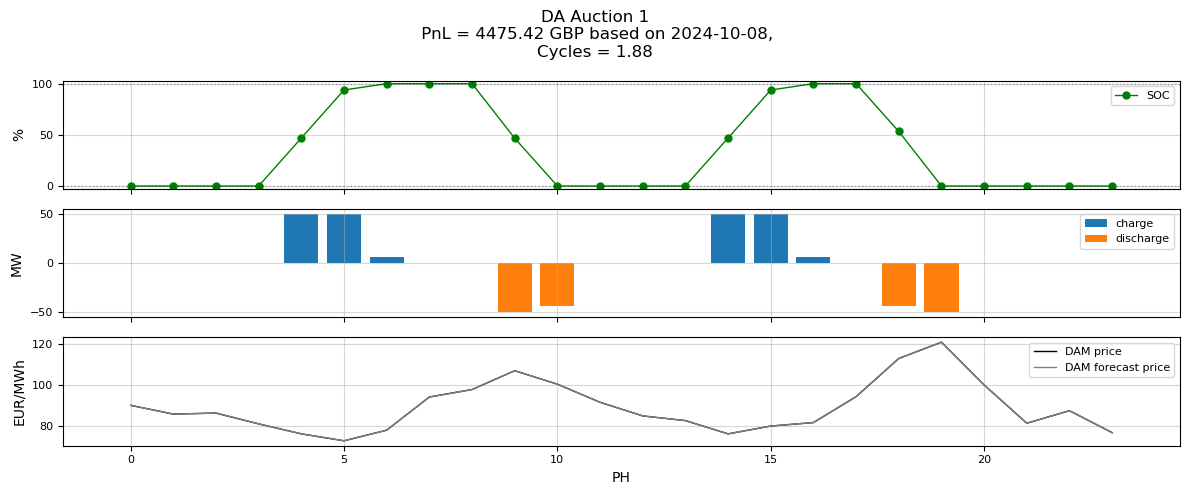

      del_date ref_date   pnl_da
70  2024-10-08     None  4475.42


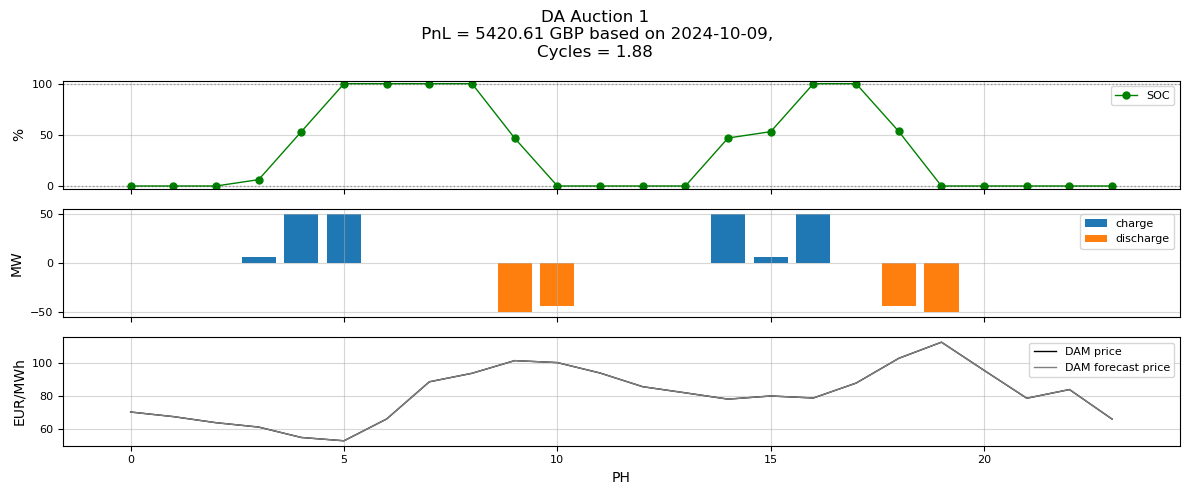

      del_date ref_date   pnl_da
71  2024-10-09     None  5420.61


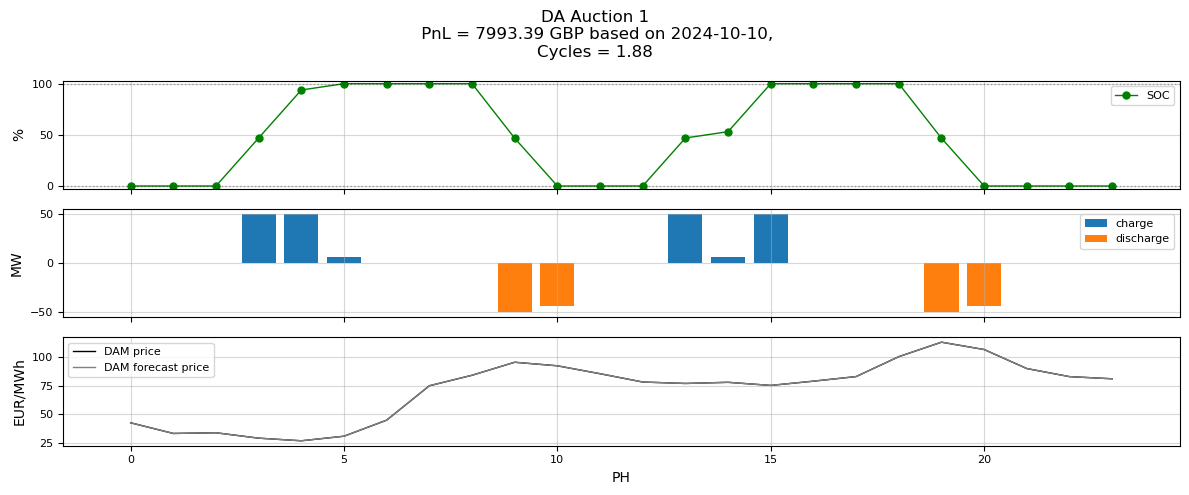

      del_date ref_date   pnl_da
72  2024-10-10     None  7993.39


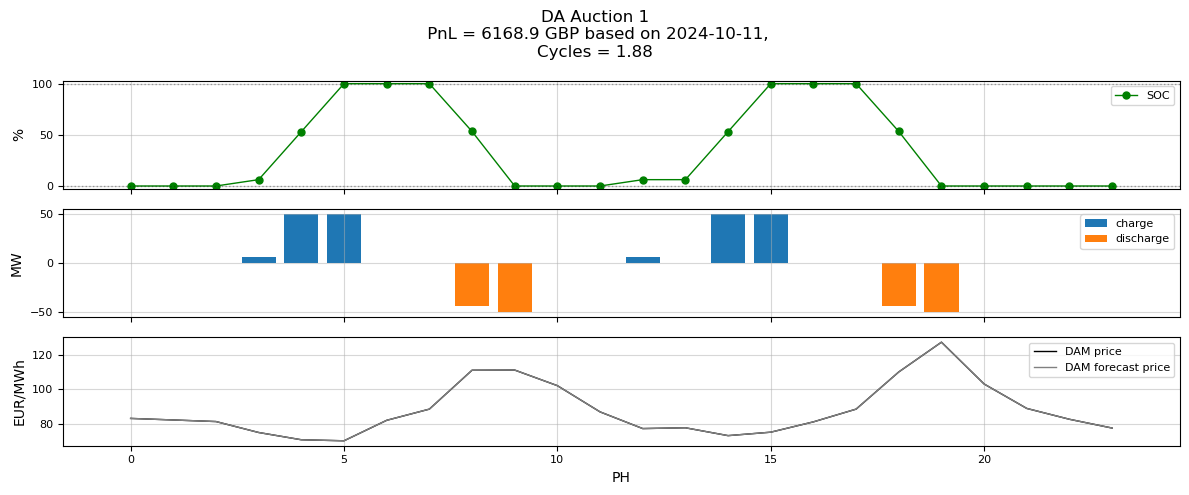

      del_date ref_date  pnl_da
73  2024-10-11     None  6168.9


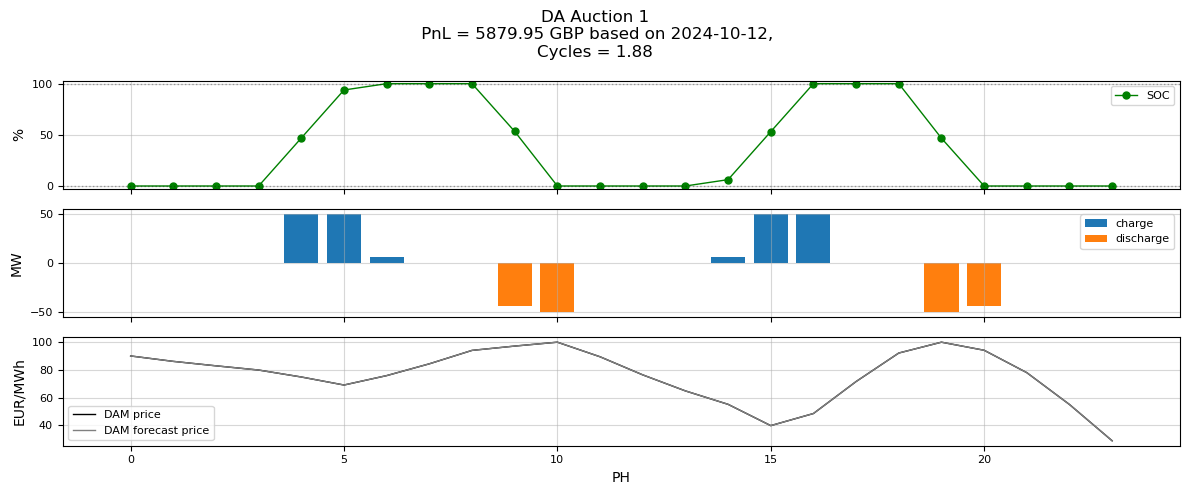

      del_date ref_date   pnl_da
74  2024-10-12     None  5879.95


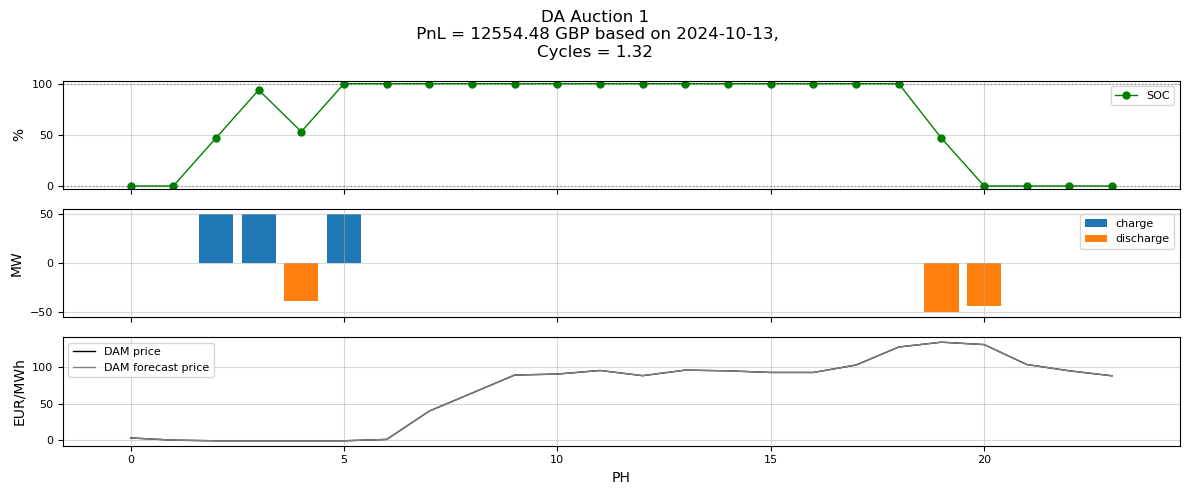

      del_date ref_date    pnl_da
75  2024-10-13     None  12554.48


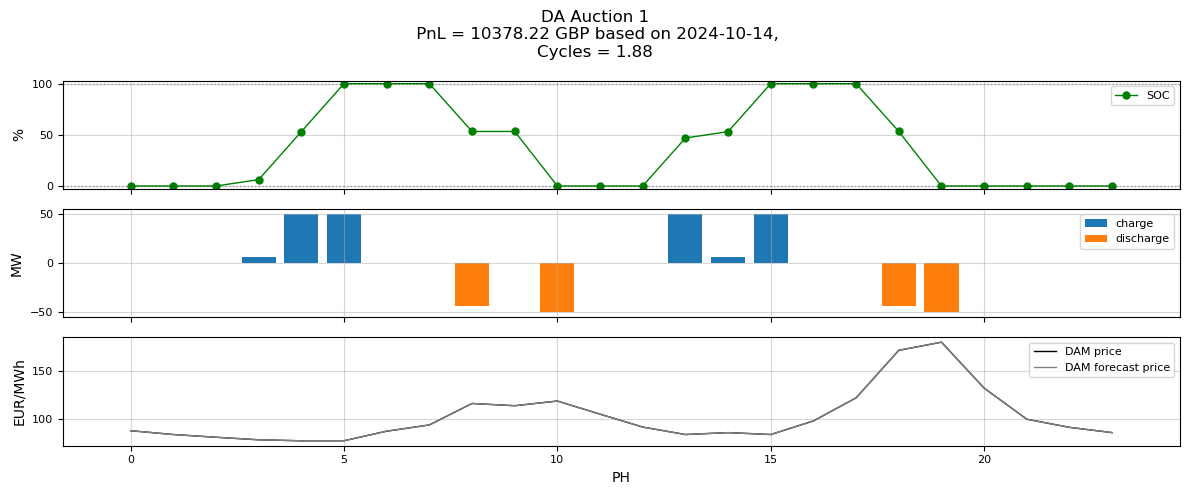

      del_date ref_date    pnl_da
76  2024-10-14     None  10378.22


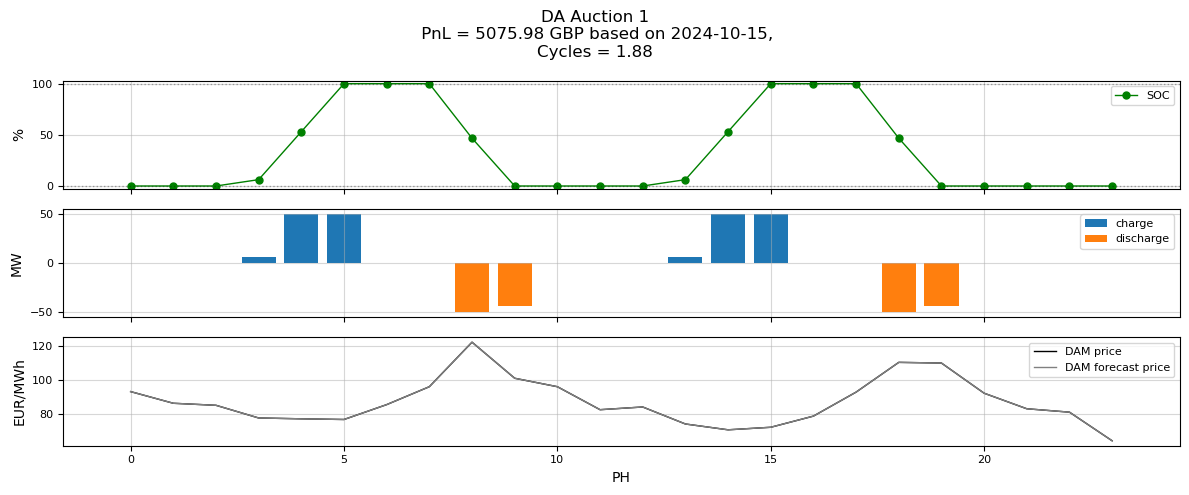

      del_date ref_date   pnl_da
77  2024-10-15     None  5075.98


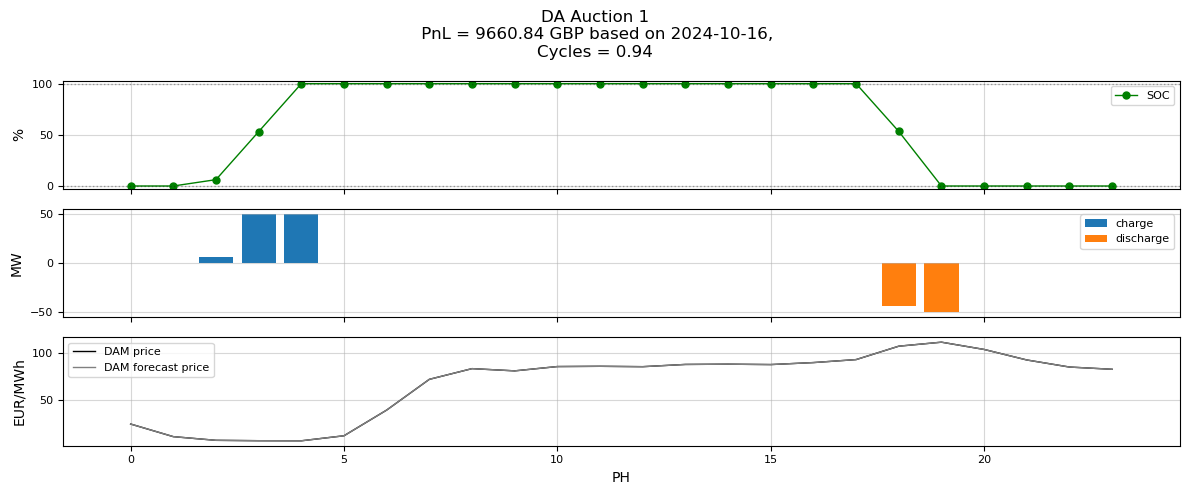

      del_date ref_date   pnl_da
78  2024-10-16     None  9660.84


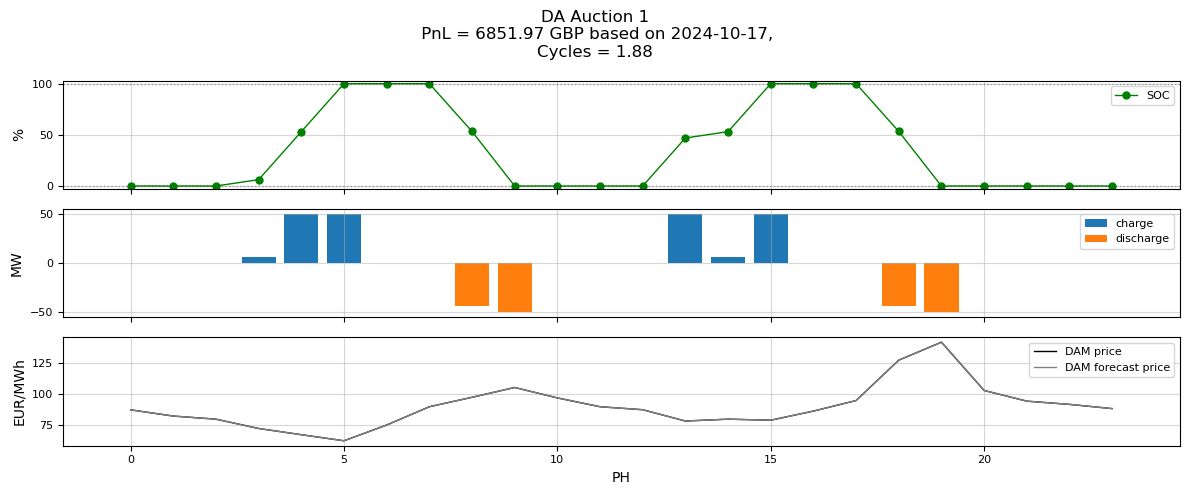

      del_date ref_date   pnl_da
79  2024-10-17     None  6851.97


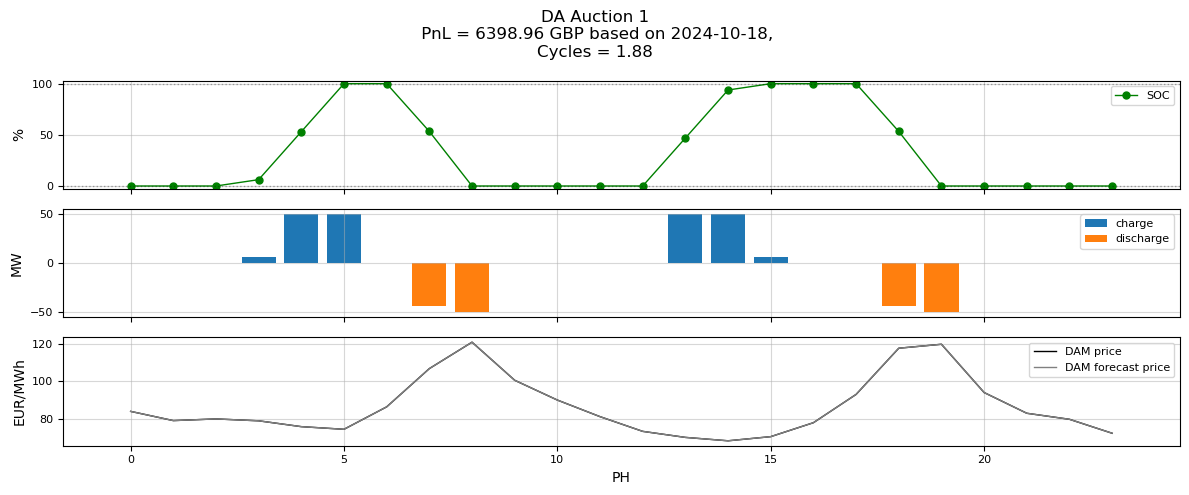

      del_date ref_date   pnl_da
80  2024-10-18     None  6398.96


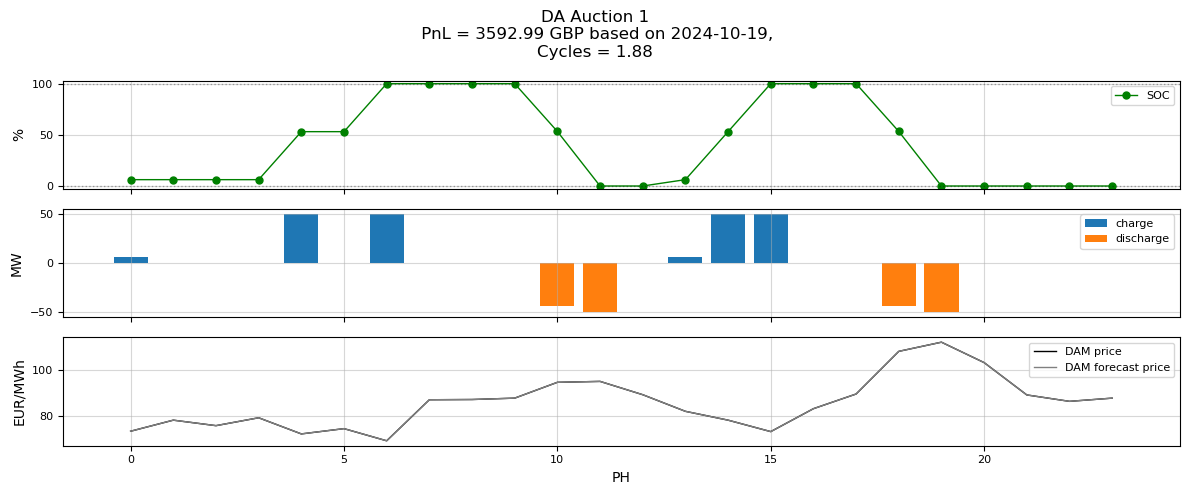

      del_date ref_date   pnl_da
81  2024-10-19     None  3592.99


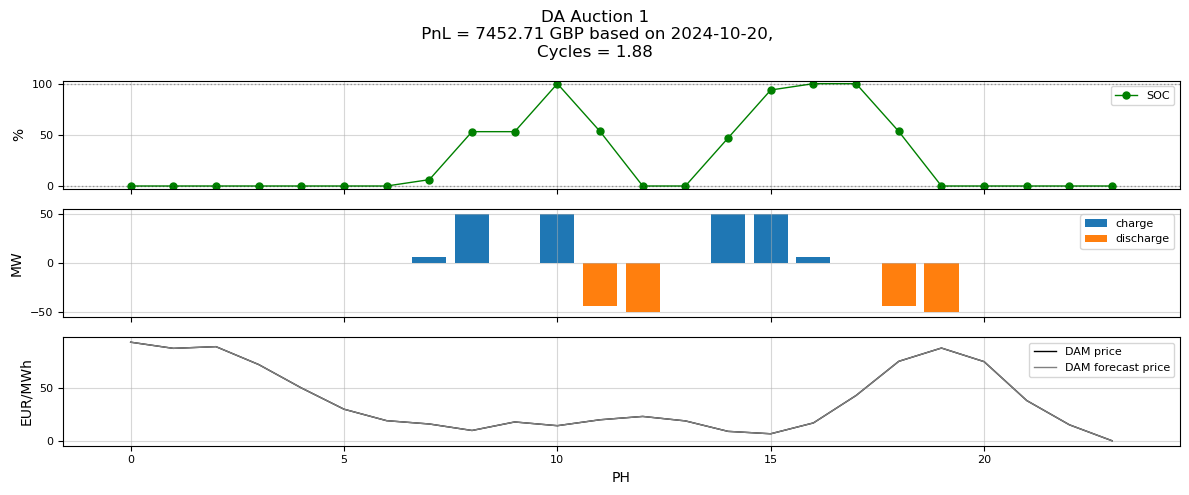

      del_date ref_date   pnl_da
82  2024-10-20     None  7452.71


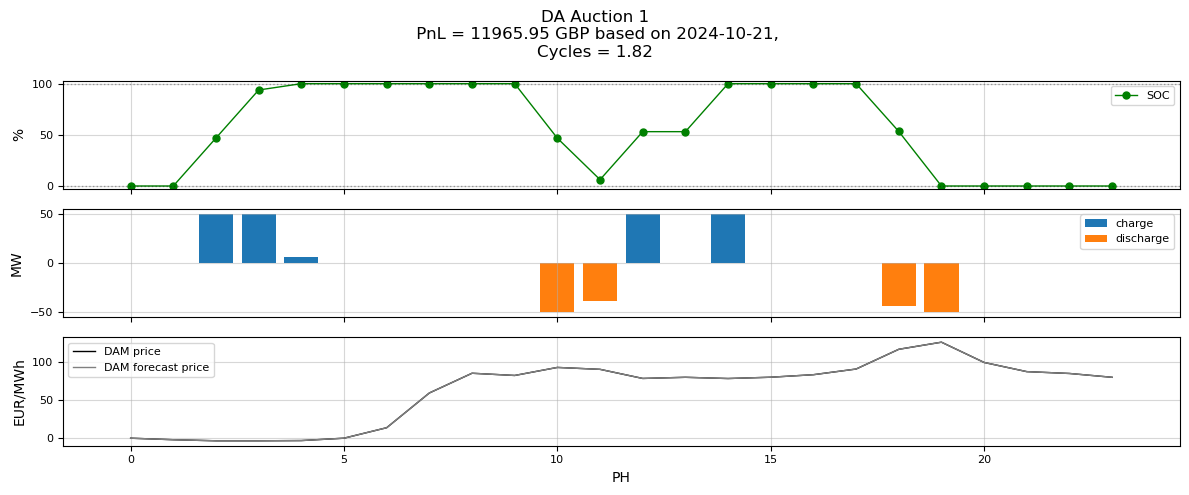

      del_date ref_date    pnl_da
83  2024-10-21     None  11965.95


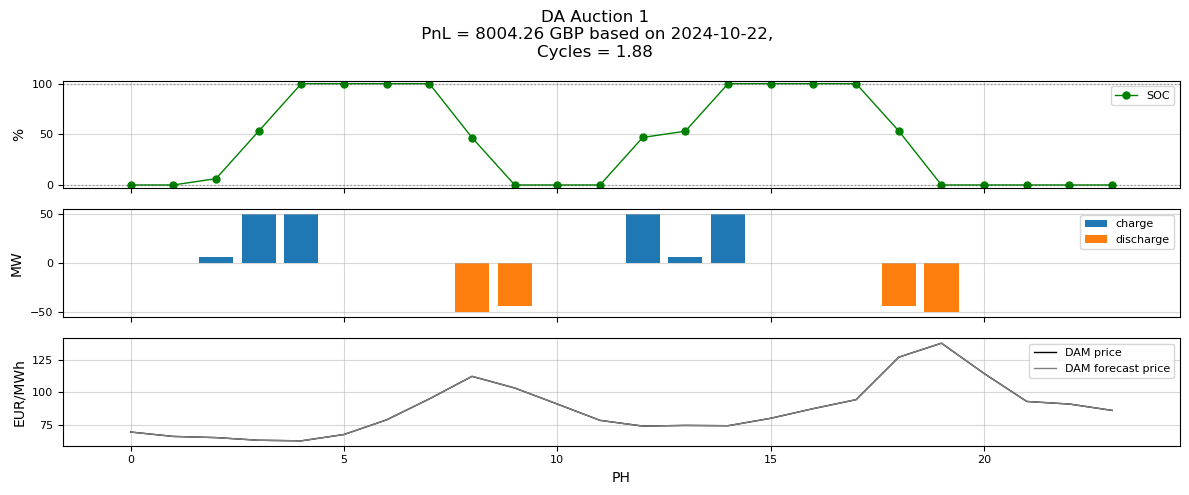

      del_date ref_date   pnl_da
84  2024-10-22     None  8004.26


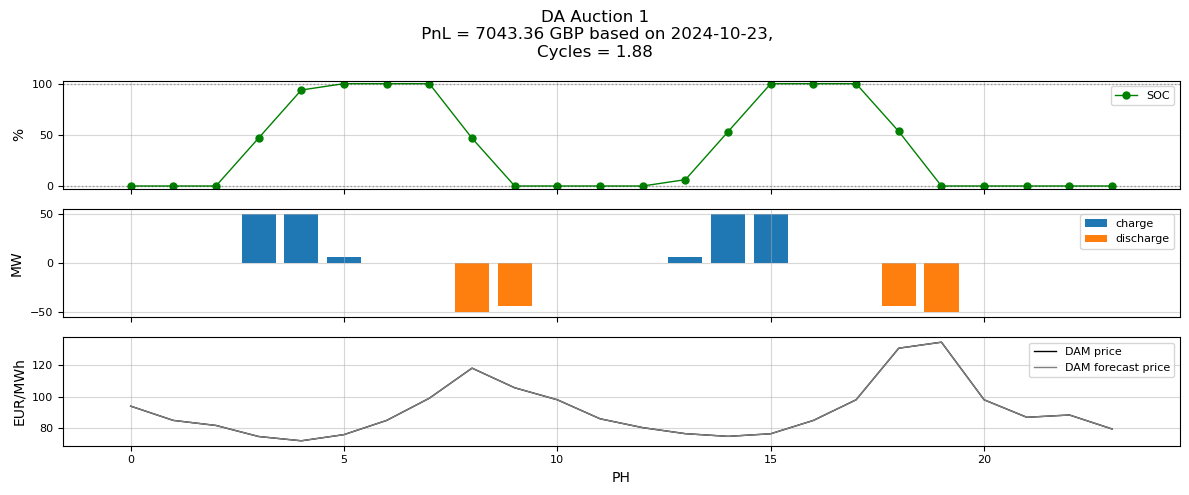

      del_date ref_date   pnl_da
85  2024-10-23     None  7043.36


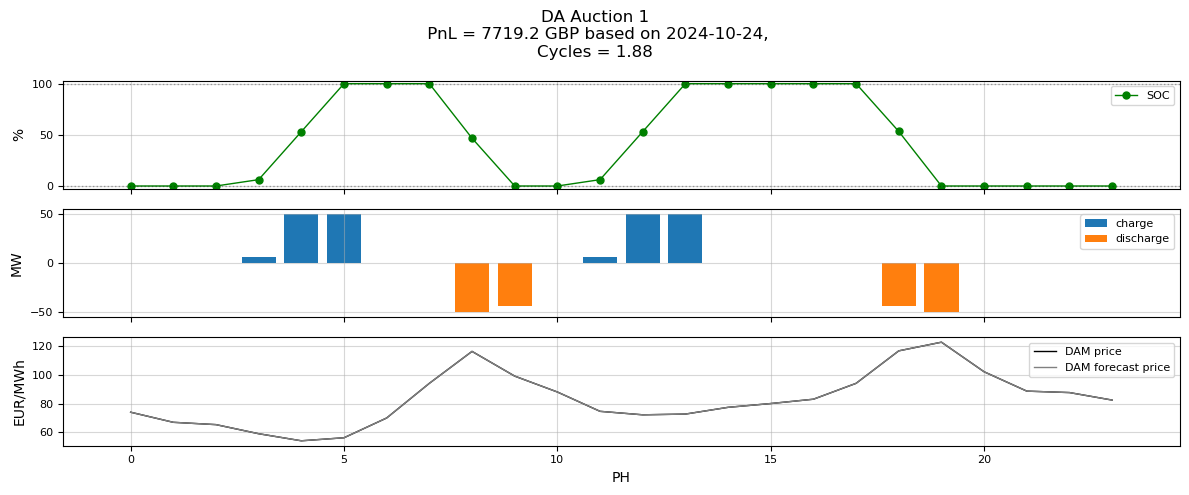

      del_date ref_date  pnl_da
86  2024-10-24     None  7719.2


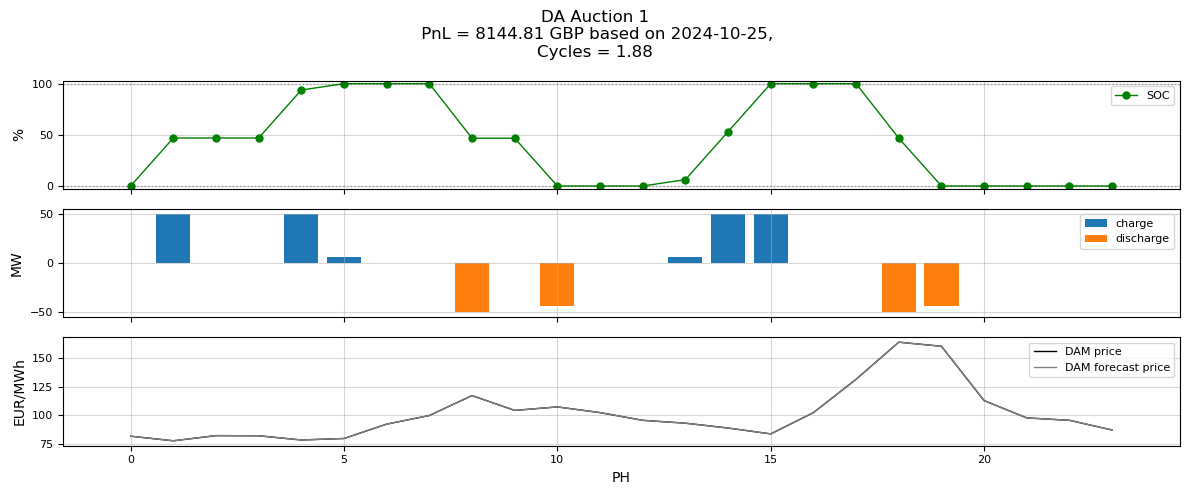

      del_date ref_date   pnl_da
87  2024-10-25     None  8144.81


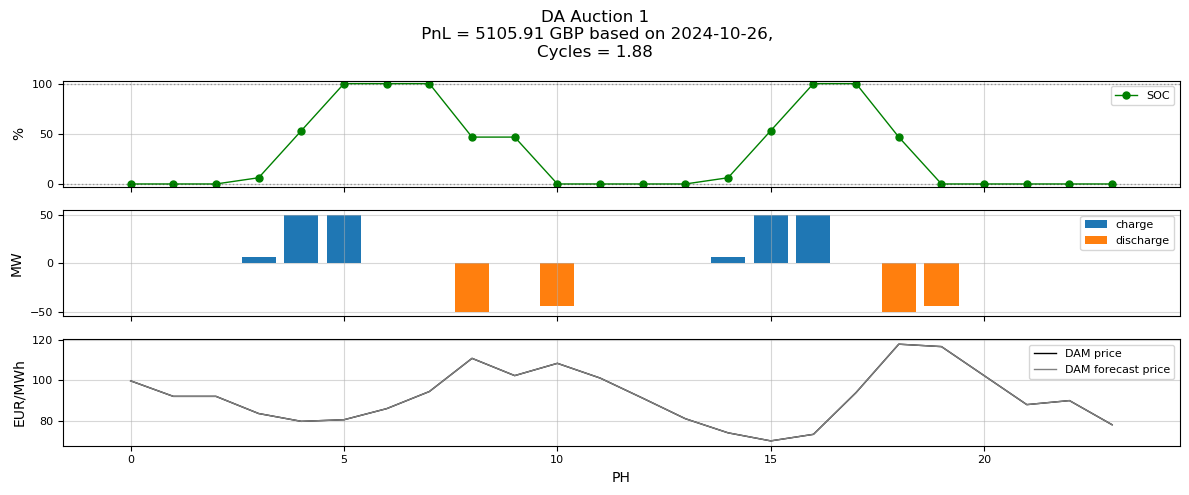

      del_date ref_date   pnl_da
88  2024-10-26     None  5105.91


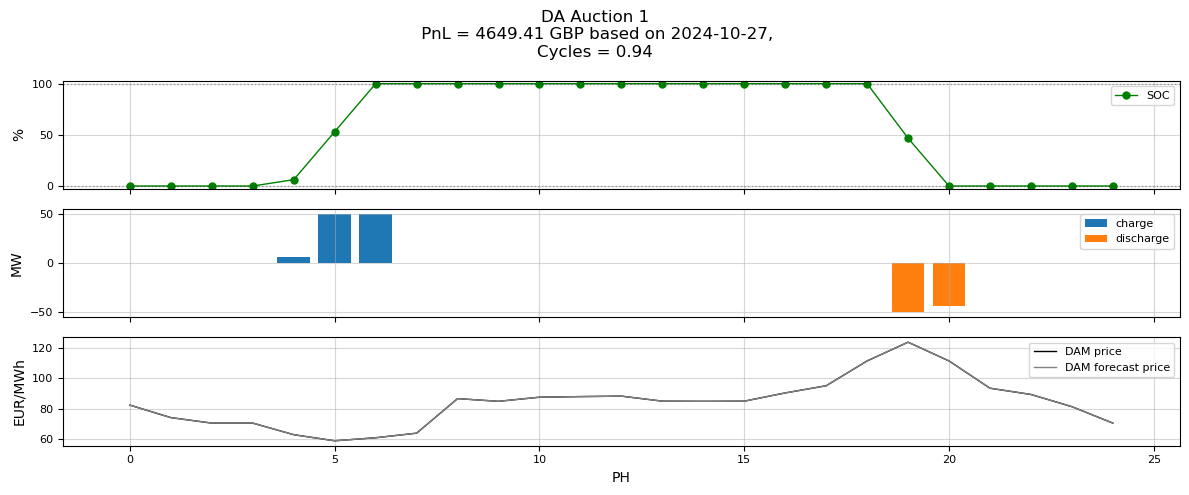

      del_date ref_date   pnl_da
89  2024-10-27     None  4649.41


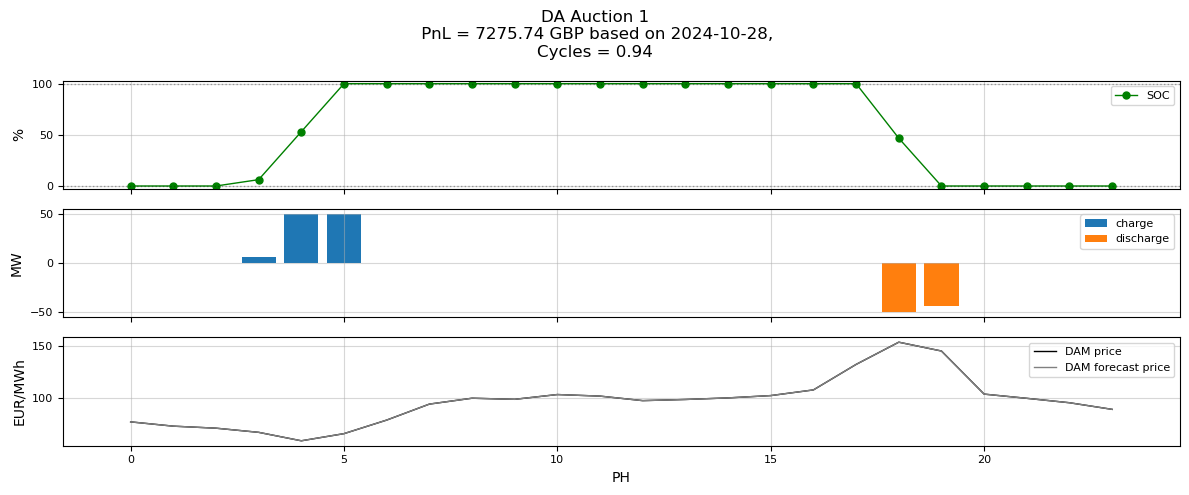

      del_date ref_date   pnl_da
90  2024-10-28     None  7275.74


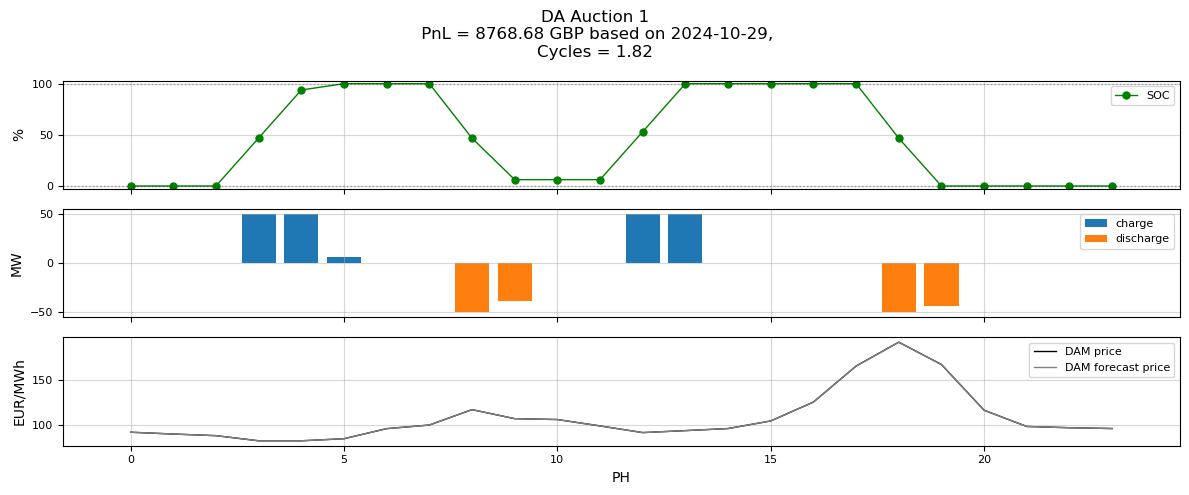

      del_date ref_date   pnl_da
91  2024-10-29     None  8768.68


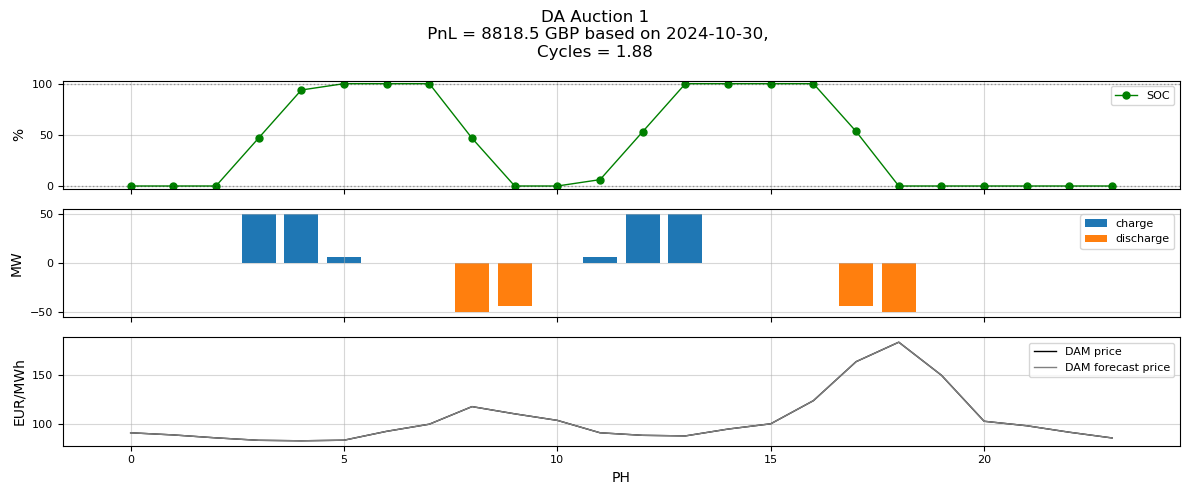

      del_date ref_date  pnl_da
92  2024-10-30     None  8818.5


In [65]:
daily_log_foresight = pd.DataFrame()    # daily logs
hourly_log_foresight = pd.DataFrame()   # hourly logs

for d in dates[:]:

    ref_date = None # for d, from your own dataset 

    # actuals, for price settlements
    del_da_data = da_data[da_data.date == d].reset_index(drop=True)
    
    # forecast for scheduling
    
    DAM_run = bess_object_dam.solving(
        dam_actual=del_da_data.da_price,  # for settlements
        dam_fc=del_da_data.da_price,   # for scheduling
        plot=show_daily_plots,  # toggle plotting here
        title_text1="DA Auction 1",
        title_text2=f"{d}",
    )
    DAM_run["dtutc"] = del_da_data.dtutc
    DAM_run["da_actual"] = del_da_data.da_price
    eod_soc = DAM_run.soc_end.iloc[-1]

    # logging
    hourly_log_foresight = pd.concat(
        [
            hourly_log_foresight,
            DAM_run[
                ["net", "soc_start", "soc_end", "dtutc", "da_actual"]
            ],
        ],
        ignore_index=True,
    )
    daily_log_foresight = pd.concat(
        [
            daily_log_foresight,
            pd.DataFrame(
                [
                    {
                        "del_date": d,
                        "ref_date": ref_date,
                        "pnl_da": bess_object_dam.pnl,
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

    bess_object_dam.init_soc = eod_soc
    print(daily_log_foresight.tail(1))

In [63]:
print("Available dates in da_data:", da_data.date.unique())
print("Checking for", d, "in da_data:", d in da_data.date.unique())


Available dates in da_data: [datetime.date(2024, 1, 1) datetime.date(2024, 1, 2)
 datetime.date(2024, 1, 3) datetime.date(2024, 1, 4)
 datetime.date(2024, 1, 5) datetime.date(2024, 1, 6)
 datetime.date(2024, 1, 7) datetime.date(2024, 1, 8)
 datetime.date(2024, 1, 9) datetime.date(2024, 1, 10)
 datetime.date(2024, 1, 11) datetime.date(2024, 1, 12)
 datetime.date(2024, 1, 13) datetime.date(2024, 1, 14)
 datetime.date(2024, 1, 15) datetime.date(2024, 1, 16)
 datetime.date(2024, 1, 17) datetime.date(2024, 1, 18)
 datetime.date(2024, 1, 19) datetime.date(2024, 1, 20)
 datetime.date(2024, 1, 21) datetime.date(2024, 1, 22)
 datetime.date(2024, 1, 23) datetime.date(2024, 1, 24)
 datetime.date(2024, 1, 25) datetime.date(2024, 1, 26)
 datetime.date(2024, 1, 27) datetime.date(2024, 1, 28)
 datetime.date(2024, 1, 29) datetime.date(2024, 1, 30)
 datetime.date(2024, 1, 31) datetime.date(2024, 2, 1)
 datetime.date(2024, 2, 2) datetime.date(2024, 2, 3)
 datetime.date(2024, 2, 4) datetime.date(2024, 2,

In [64]:
da_data["date"] = pd.to_datetime(da_data["date"])
d = pd.to_datetime(d)


In [66]:
daily_log_foresight.to_csv("perfect_foresight_da_pnl.csv", index=False)

In [67]:
daily_log_foresight

,del_date,ref_date,pnl_da
0,2024-07-30,None,3525.03
1,2024-07-31,None,3090.89
2,2024-08-01,None,3360.64
3,2024-08-02,None,4499.91
4,2024-08-03,None,3304.46
...,...,...,...
88,2024-10-26,None,5105.91
89,2024-10-27,None,4649.41
90,2024-10-28,None,7275.74
91,2024-10-29,None,8768.68


In [68]:
benchmark = daily_log_foresight.pnl_da.sum()
benchmark


632474.0900000002

In [70]:
dates = df_euclidean.date.unique()
dates

array(['2024-07-30', '2024-07-31', '2024-08-01', '2024-08-02',
       '2024-08-03', '2024-08-04', '2024-08-05', '2024-08-06',
       '2024-08-07', '2024-08-08', '2024-08-09', '2024-08-10',
       '2024-08-11', '2024-08-12', '2024-08-13', '2024-08-14',
       '2024-08-15', '2024-08-16', '2024-08-17', '2024-08-18',
       '2024-08-19', '2024-08-20', '2024-08-21', '2024-08-22',
       '2024-08-23', '2024-08-24', '2024-08-25', '2024-08-26',
       '2024-08-27', '2024-08-28', '2024-08-29', '2024-08-30',
       '2024-08-31', '2024-09-01', '2024-09-02', '2024-09-03',
       '2024-09-04', '2024-09-05', '2024-09-06', '2024-09-07',
       '2024-09-08', '2024-09-09', '2024-09-10', '2024-09-11',
       '2024-09-12', '2024-09-13', '2024-09-14', '2024-09-15',
       '2024-09-16', '2024-09-17', '2024-09-18', '2024-09-19',
       '2024-09-20', '2024-09-21', '2024-09-22', '2024-09-23',
       '2024-09-24', '2024-09-25', '2024-09-26', '2024-09-27',
       '2024-09-28', '2024-09-29', '2024-09-30', '2024-

In [71]:
bess_object_dam = day_ahead(
    size=SIZE,
    power_up=POWER_UP,
    power_down=POWER_DOWN,
    timestep=1,
    charge_eff=CHARGE_EFFICIENCY,
    discharge_eff=DISCHARGE_EFFICIENCY,
    manual_soc_max=MANUAL_SOC_MAX,
    manual_soc_min=MANUAL_SOC_MIN,
    init_soc=INIT_SOC,
    end_soc=END_SOC,
    end_soc_limit_type=end_soc_limit_type,
    daily_cycle_max=MAX_THROUGHPUT_CYCLES,
    throughput_size=THROUGHPUT_SIZE,
    solution_time_limit=SOLUTION_TIME_LIMIT_SEC,
    integer_solution=INTEGER_PN,
)

In [83]:
# daily_log_refModel1 = pd.DataFrame()    # daily logs
# hourly_log_refModel1 = pd.DataFrame()   # hourly logs

# for del_date in dates[:]:

#     ref_date = df_euclidean[df_euclidean.date == del_date].closest_reference_days.iloc[0]
    
    

#     # actuals, for price settlements
#     del_da_data = da_data[da_data.date == del_date].reset_index(drop=True)
    
#     # forecast for scheduling
#     ref_da_data = da_data[da_data.date == ref_date].reset_index(drop=True)
    
#     DAM_run = bess_object_dam.solving(
#         dam_actual=del_da_data.da_price,  # for settlements
#         dam_fc=ref_da_data.da_price,   # for scheduling
#         plot=show_daily_plots,  # toggle plotting here
#         title_text1="DA Auction 1",
#         title_text2=f"{del_date}, ref date = {ref_date}",
#     )
#     DAM_run["dtutc"] = del_da_data.dtutc
#     DAM_run["da_actual"] = del_da_data.da_price
#     eod_soc = DAM_run.soc_end.iloc[-1]

#     # logging
#     hourly_log_refModel1 = pd.concat(
#         [
#             hourly_log_refModel1,
#             DAM_run[
#                 ["net", "soc_start", "soc_end", "dtutc", "da_actual"]
#             ],
#         ],
#         ignore_index=True,
#     )
#     daily_log_refModel1 = pd.concat(
#         [
#             daily_log_refModel1,
#             pd.DataFrame(
#                 [
#                     {
#                         "del_date": del_date,
#                         "ref_date": ref_date,
#                         "pnl_da": bess_object_dam.pnl,
#                     }
#                 ]
#             ),
#         ],
#         ignore_index=True,
#     )

#     bess_object_dam.init_soc = eod_soc
#     print(daily_log_refModel1.tail(1))

IndexError: index -1 is out of bounds for axis 0 with size 0

In [97]:
print(df_euclidean.columns)


Index(['date', 'closest_reference_days', 'distance'], dtype='object')


In [79]:
# Check the first few values
print(df["closest_reference_days"].head())
print(df["closest_reference_days"].dtype)


0    [Timestamp('2024-07-18 00:00:00'), Timestamp('...
1    [Timestamp('2024-06-24 00:00:00'), Timestamp('...
2    [Timestamp('2024-06-25 00:00:00'), Timestamp('...
3    [Timestamp('2024-07-19 00:00:00'), Timestamp('...
4    [Timestamp('2024-06-22 00:00:00'), Timestamp('...
Name: closest_reference_days, dtype: object
object


In [98]:
# Loop through your DataFrame starting from "lookback" so you have enough past data.
for i in range(lookback, len(df)):
    current_day = df.iloc[i]
    # Select only the previous `lookback` days
    past_days = df.iloc[i - lookback:i]

    distances = []
    # Note: current_day[1:] and past_day[1:] assume that the first column is "date"
    for _, past_day in past_days.iterrows():
        d = euclidean(current_day.iloc[1:].astype(float), past_day.iloc[1:].astype(float))
        distances.append((past_day["date"], d))

    # Get the candidate with the minimum distance
    best_ref_day, best_dist = min(distances, key=lambda x: x[1])
    reference_rows.append({
        "date": current_day["date"],
        "closest_reference_day": best_ref_day,
        "euclidean_distance": best_dist
    })

return pd.DataFrame(reference_rows)


NameError: name 'lookback' is not defined

In [111]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import ast

# # Read the actual day‐ahead prices and compute revenue per day [5]
# df_actual = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", parse_dates=["dtutc", "dtcet", "date"])
# # Group by date (taking only the date part) and sum the DA prices
# actual_revenue = df_actual.groupby('date')['da_price'].sum().reset_index()
# actual_revenue.rename(columns={'da_price':'revenue'}, inplace=True)
# actual_revenue['date'] = actual_revenue['date'].dt.date

# # ---------------------------
# # Cosine metric forecast
# # Read the cosine reference day table [2]
# df_cosine = pd.read_csv("../src/data/processed/reference_days_cosine_table.csv", parse_dates=["date"])
# # Convert the stored string representation of the list into an actual list of Timestamps
# df_cosine["closest_reference_days"] = df_cosine["closest_reference_days"].apply(lambda x: ast.literal_eval(x))
# # Pick the first reference day as the forecast candidate
# df_cosine["best_ref_day"] = df_cosine["closest_reference_days"].apply(lambda lst: lst[0] if isinstance(lst, list) and len(lst) > 0 else pd.NaT)

# # Prepare columns for merging: convert to date
# df_cosine["target_date"] = df_cosine["date"].dt.date
# df_cosine["ref_date"] = df_cosine["best_ref_day"].dt.date

# # Merge with actual revenue: first join to get perfect revenue for the target day
# df_cosine = df_cosine.merge(actual_revenue, left_on="target_date", right_on="date", how="left", suffixes=("", "_target"))
# # Then merge to get the revenue for the forecast (reference) day
# df_cosine = df_cosine.merge(actual_revenue, left_on="ref_date", right_on="date", how="left", suffixes=("", "_ref"))
# # Compute the revenue ratio (forecast revenue as a percentage of the perfect revenue)
# df_cosine["revenue_ratio"] = (df_cosine["revenue_ref"] / df_cosine["revenue"]) * 100

# # Plot the revenue ratio over target days
# plt.figure(figsize=(10,6))
# plt.plot(df_cosine["target_date"], df_cosine["revenue_ratio"], marker="o", linestyle='-')
# plt.xlabel("Target Date")
# plt.ylabel("Revenue Ratio (%)")
# plt.title("Revenue Ratio using Cosine Metric Forecast")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


ValueError: malformed node or string on line 1: <ast.Call object at 0x00000144C210F9A0>

In [112]:
import pandas as pd

df_cosine = pd.read_csv("../src/data/processed/reference_days_cosine_table.csv", parse_dates=["date"])
print(df_cosine["closest_reference_days"].head())


0    [Timestamp('2024-06-25 00:00:00'), Timestamp('...
1    [Timestamp('2024-06-21 00:00:00'), Timestamp('...
2    [Timestamp('2024-07-18 00:00:00'), Timestamp('...
3    [Timestamp('2024-06-14 00:00:00'), Timestamp('...
4    [Timestamp('2024-07-10 00:00:00'), Timestamp('...
Name: closest_reference_days, dtype: object


In [ ]:
# import pandas as pd
# import numpy as np
# from optimization_logic import day_ahead

# # Load actual DA prices
# dam_actual = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", index_col=0, parse_dates=True)

# # Load reference day tables
# ref_corr = pd.read_csv("../src/data/processed/reference_days_correlation_table.csv")
# ref_cosine = pd.read_csv("../src/data/processed/reference_days_cosine_table.csv")
# ref_euclidean = pd.read_csv("../src/data/processed/reference_days_euclidean_table.csv")

# # Function to get reference day prices
# def get_reference_prices(ref_table, dam_actual):
#     ref_prices = []
#     for _, row in ref_table.iterrows():
#     try:
#     ref_dates = eval(row['closest_reference_days']) if isinstance(row['closest_reference_days'], str) else row['closest_reference_days']
#     ref_date = pd.to_datetime(ref_dates[0])  # Take the first closest reference day
# except Exception as e:
#     print(f"Error parsing reference day for {row['date']}: {e}")
#     continue
#         if ref_date in dam_actual.index:
#             ref_prices.append(dam_actual.loc[ref_date].values)
#         else:
#             ref_prices.append(np.nan)  # Handle missing reference days
#     return pd.Series(ref_prices, index=pd.to_datetime(ref_table['date']))

# # Retrieve DA prices for reference days
# dam_corr = get_reference_prices(ref_corr, dam_actual)
# dam_cosine = get_reference_prices(ref_cosine, dam_actual)
# dam_euclidean = get_reference_prices(ref_euclidean, dam_actual)

# # Optimization parameters (adjust as needed)
# params = {
#     "size": 100,
#     "power_up": 50,
#     "power_down": 50,
#     "timestep": 1,
#     "charge_eff": 0.9,
#     "discharge_eff": 0.9,
#     "manual_soc_max": 100,
#     "manual_soc_min": 0,
#     "solution_time_limit": 30,
# }

# # Run optimization for each method
# optimizer = day_ahead(**params)
# schedule_corr = optimizer.solving(dam_actual=dam_actual, dam_fc=dam_corr, plot=False)
# schedule_cosine = optimizer.solving(dam_actual=dam_actual, dam_fc=dam_cosine, plot=False)
# schedule_euclidean = optimizer.solving(dam_actual=dam_actual, dam_fc=dam_euclidean, plot=False)

# # Compute revenues
# perfect_revenue = abs(optimizer.pnl)
# revenue_corr = abs(schedule_corr["net"].sum() * params["timestep"])
# revenue_cosine = abs(schedule_cosine["net"].sum() * params["timestep"])
# revenue_euclidean = abs(schedule_euclidean["net"].sum() * params["timestep"])

# # Calculate % of perfect foresight
# percentage_corr = (revenue_corr / perfect_revenue) * 100
# percentage_cosine = (revenue_cosine / perfect_revenue) * 100
# percentage_euclidean = (revenue_euclidean / perfect_revenue) * 100

# # Print results
# print(f"Correlation-based revenue: {percentage_corr:.2f}% of perfect foresight")
# print(f"Cosine-based revenue: {percentage_cosine:.2f}% of perfect foresight")
# print(f"Euclidean-based revenue: {percentage_euclidean:.2f}% of perfect foresight")


In [117]:
import pandas as pd

cosine_df = pd.read_csv("../src/data/processed/reference_days_cosine_table.csv", parse_dates=["date"])
actual_prices = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", parse_dates=["date", "dtutc", "dtcet"])

cosine_df["closest_reference_day"] = cosine_df["closest_reference_days"].apply(
    lambda x: eval(x, {"Timestamp": pd.Timestamp})[0] if isinstance(x, str) else None
)

daily_actual_revenue = actual_prices.groupby("date")["da_price"].sum().reset_index()
daily_actual_revenue.columns = ["del_date", "pnl_da_foresight"]

cosine_df = cosine_df.merge(
    daily_actual_revenue,
    left_on="closest_reference_day",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_ref"})

compare_df = cosine_df.merge(
    daily_actual_revenue,
    left_on="date",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_foresight"})

total_ref_revenue = compare_df["pnl_da_ref"].sum()
total_foresight_revenue = compare_df["pnl_da_foresight"].sum()
perfect_foresight_ratio = (total_ref_revenue / total_foresight_revenue) * 100

print(f"Perfect Foresight Ratio (Cosine): {perfect_foresight_ratio:.2f}%")


Perfect Foresight Ratio (Cosine): 96.83%


In [122]:
import pandas as pd

euclidean_df = pd.read_csv("../src/data/processed/reference_days_euclidean_table.csv", parse_dates=["date"])
actual_prices = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", parse_dates=["date", "dtutc", "dtcet"])

euclidean_df["closest_reference_day"] = euclidean_df["closest_reference_days"].apply(
    lambda x: eval(x, {"Timestamp": pd.Timestamp})[0] if isinstance(x, str) else None
)

daily_actual_revenue = actual_prices.groupby("date")["da_price"].sum().reset_index()
daily_actual_revenue.columns = ["del_date", "pnl_da_foresight"]

euclidean_df = euclidean_df.merge(
    daily_actual_revenue,
    left_on="closest_reference_day",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_ref"})

compare_df = euclidean_df.merge(
    daily_actual_revenue,
    left_on="date",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_foresight"})

total_ref_revenue = compare_df["pnl_da_ref"].sum()
total_foresight_revenue = compare_df["pnl_da_foresight"].sum()
perfect_foresight_ratio = (total_ref_revenue / total_foresight_revenue) * 100

print(f"Perfect Foresight Ratio (Euclidean): {perfect_foresight_ratio:.2f}%")


Perfect Foresight Ratio (Euclidean): 96.95%


In [123]:
import pandas as pd

corr_df = pd.read_csv("../src/data/processed/reference_days_correlation_table.csv", parse_dates=["date"])
actual_prices = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", parse_dates=["date", "dtutc", "dtcet"])

corr_df["closest_reference_day"] = corr_df["closest_reference_days"].apply(
    lambda x: eval(x, {"Timestamp": pd.Timestamp})[0] if isinstance(x, str) else None
)

daily_actual_revenue = actual_prices.groupby("date")["da_price"].sum().reset_index()
daily_actual_revenue.columns = ["del_date", "pnl_da_foresight"]

corr_df = corr_df.merge(
    daily_actual_revenue,
    left_on="closest_reference_day",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_ref"})

compare_df = corr_df.merge(
    daily_actual_revenue,
    left_on="date",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_foresight"})

total_ref_revenue = compare_df["pnl_da_ref"].sum()
total_foresight_revenue = compare_df["pnl_da_foresight"].sum()
perfect_foresight_ratio = (total_ref_revenue / total_foresight_revenue) * 100

print(f"Perfect Foresight Ratio (Correlation): {perfect_foresight_ratio:.2f}%")


Perfect Foresight Ratio (Correlation): 97.36%


In [124]:
# from optimization_logic import dayahead_lp_optimization  

# def calculate_perfect_foresight(actual_prices):
#     results = dayahead_lp_optimization(prices=actual_prices)
#     return results["total_revenue"]

# def calculate_reference_day_revenue(reference_prices, actual_prices):
#     results = dayahead_lp_optimization(prices=reference_prices)
#     settled_revenue = settle_on_actuals(results["schedule"], actual_prices)
#     return settled_revenue

# for metric_file in ["reference_days_cosine_table.csv", "reference_days_euclidean_table.csv", "reference_days_correlation_table.csv"]:
#     metric_df = pd.read_csv(metric_file)
#     metric_df["closest_reference_day"] = metric_df["closest_reference_days"].apply(
#         lambda x: eval(x, {"Timestamp": pd.Timestamp})[0] if isinstance(x, str) else None
#     )
    
#     perfect_revenues = []
#     reference_revenues = []
    
#     for _, row in metric_df.iterrows():
#         target_date = row["date"]
#         ref_date = row["closest_reference_day"]
        
#         target_prices = get_prices_for_date(target_date, actual_prices)
#         ref_prices = get_prices_for_date(ref_date, actual_prices)
        
#         if target_prices.empty or ref_prices.empty:
#             continue
        
#         perfect_revenue = calculate_perfect_foresight(target_prices)
#         perfect_revenues.append(perfect_revenue)
        
#         ref_revenue = calculate_reference_day_revenue(ref_prices, target_prices)
#         reference_revenues.append(ref_revenue)
    
#     total_perfect_revenue = sum(perfect_revenues)
#     total_reference_revenue = sum(reference_revenues)
#     ratio = (total_reference_revenue / total_perfect_revenue) * 100
    
#     print(f"Perfect Foresight Ratio ({metric_file}): {ratio:.2f}%")


In [126]:
import pandas as pd
from optimization_logic import dayahead_lp_optimization 

ref_df = pd.read_csv("../src/data/processed/reference_days.csv", parse_dates=["date"])
actual_prices = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", parse_dates=["date", "dtutc", "dtcet"])

ref_df["closest_reference_day"] = ref_df["closest_reference_days"].apply(
    lambda x: eval(x, {"Timestamp": pd.Timestamp})[0] if isinstance(x, str) else None
)

daily_actual_revenue = actual_prices.groupby("date")["da_price"].sum().reset_index()
daily_actual_revenue.columns = ["del_date", "pnl_da_foresight"]

ref_df = ref_df.merge(
    daily_actual_revenue,
    left_on="closest_reference_day",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_ref"})

compare_df = ref_df.merge(
    daily_actual_revenue,
    left_on="date",
    right_on="del_date",
    how="left"
).rename(columns={"pnl_da_foresight": "pnl_da_foresight"})

total_ref_revenue = compare_df["pnl_da_ref"].sum()
total_foresight_revenue = compare_df["pnl_da_foresight"].sum()
perfect_foresight_ratio = (total_ref_revenue / total_foresight_revenue) * 100

print(f"Perfect Foresight Ratio (Correlation): {perfect_foresight_ratio:.2f}%")


Perfect Foresight Ratio (Correlation): 91.95%


In [131]:
# import os
# import sys
# src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
# sys.path.append(src_path)
# from optimization_logic import *

In [130]:
# import pandas as pd
# import numpy as np
# import re

# # Load reference days and actual DA prices
# ref_df = pd.read_csv("../src/data/processed/reference_days.csv", parse_dates=["date"])
# actual_prices = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv", parse_dates=["date", "dtutc", "dtcet"])

# # Parse 'closest_reference_days' to extract the first reference day
# def parse_closest_reference_days(row):
#     try:
#         # Use regex to extract all dates from the string
#         date_matches = re.findall(r"Timestamp\('([^']+)'\)", row)
#         # Return the first date if available
#         return pd.to_datetime(date_matches[0]).date() if len(date_matches) > 0 else None
#     except Exception as e:
#         print(f"Error parsing row: {row}, Error: {e}")
#         return None

# ref_df["closest_reference_day"] = ref_df["closest_reference_days"].apply(parse_closest_reference_days)

# # Aggregate actual prices by date to get daily revenues
# daily_actual_revenue = actual_prices.groupby("date")["da_price"].sum().reset_index()
# daily_actual_revenue.columns = ["del_date", "pnl_da_foresight"]

# # Merge reference day revenues into ref_df
# ref_df = ref_df.merge(
#     daily_actual_revenue,
#     left_on="closest_reference_day",
#     right_on="del_date",
#     how="left"
# ).rename(columns={"pnl_da_foresight": "pnl_da_ref"})

# # Merge actual delivery day revenues into ref_df
# compare_df = ref_df.merge(
#     daily_actual_revenue,
#     left_on="date",
#     right_on="del_date",
#     how="left"
# ).rename(columns={"pnl_da_foresight": "pnl_da_foresight"})

# # Handle missing values in 'pnl_da_ref' using forward fill (ffill)
# compare_df["pnl_da_ref"] = compare_df["pnl_da_ref"].fillna(method="ffill")

# # Calculate total revenues for reference and delivery days
# total_ref_revenue = compare_df["pnl_da_ref"].sum()
# total_foresight_revenue = compare_df["pnl_da_foresight"].sum()

# # Calculate perfect foresight ratio
# perfect_foresight_ratio = (total_ref_revenue / total_foresight_revenue) * 100

# # Print results
# print(f"Perfect Foresight Ratio: {perfect_foresight_ratio:.2f}%")

# # Debugging: Check rows with NaN values in 'pnl_da'
# nan_rows = compare_df[pd.isna(compare_df["pnl_da_ref"])]
# print("\nRows with NaN in 'pnl_da_ref':")
# print(nan_rows)

# # Save the processed DataFrame to a CSV file if needed
# compare_df.to_csv("../src/data/processed/processed_reference_days.csv", index=False)
